<a href="https://colab.research.google.com/github/cuzmyk/machine_learning/blob/main/2s_10pr.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Библиотеки, используемые для обработки данных ДЗЗ в среде программирования Python

# Раздел 1. Введение










На этом этом практическом занятии Вы познакомитесь с обработкой, визуализацией и анализом геопространственных данных в браузере с помощью высокоуровневых географических библиотек Python и Google Сolaboratory.

Практическое занятие состоит из 4 разделов: "Введение", "Работа с векторными данными в библиотеке Geopandas", "Работа с растровыми данными в библиотеке Rasterio" и "Визуализация геоданных":  



* В первом разделе мы рассмотрим, как использовать Google Colab и установить необходимые библиотеки Python.

* Во втором разделе мы научимся обрабатывать геопространственные данные с помощью библиотеки Geopandas. Мы выполним несколько наиболее часто используемых ГИС-задач без использования программ для настольных ГИС. Среди этих задач - загрузка пространственных данных, работа с геоданными, проекциями и системами координат, а также выполнение пространственных соединений, наложения и буферного анализа.

* В третьем разделе будут рассмотрены, прежде всего, некоторые полезные функции обработки растровых данных. Основной библиотекой, используемой в этом разделе, будет RasterIO, очень удобный инструмент для растрового анализа.

* Четвертый раздел посвящен, прежде всего, визуализации географических данных и картографии на Python. Здесь мы будем создавать как статические, так и интерактивные карты с помощью Geopandas, Plotly Express и библиотеки Folium.



### 1.2 Установка и данные

Геопространственные библиотеки не установлены в google colab как стандартные библиотеки python, поэтому для их использования нам необходимо их установить. Для этого можно воспользоваться командами !apt install или !pip install.

Вот список библиотек, которые нам нужно установить:

1.   Gdal
2.   Geopandas
3.   Rasterio
4.   Folium

Установка может занять от 1 до 3 минут.

In [ ]:
%%time
!apt update
!apt upgrade
# Библиотека, необходимая для работы других библиотек
!apt install gdal-bin python-gdal python3-gdal
# Установка rtree - требование Geopandas
!apt install python3-rtree
# Установка Geopandas
!pip install git+git://github.com/geopandas/geopandas.git
# Установка descartes - Geopandas requirment
!pip install descartes
# Установка rasterio for raster data
!pip install rasterio
# Установка Folium для визуализации геоданных
!pip install folium
# распаковка набора данных
!apt-get install xz-utils
# Установка pysal для составления тематических карт в Geopandas
!pip install pysal

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,626 B]
Get:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:3 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:4 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [893 kB]
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Hit:7 https://ppa.launchpadcontent.net/c2d4u.team/c2d4u4.0+/ubuntu jammy InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Get:9 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [1,858 kB]
Hit:10 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Get:11 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease [24.3 kB]
Get:12 http://archive.ubuntu.com/ubuntu jammy-updates/restricted amd64 Packages [2,512 kB]
Hit:13 https://

Импортируем набор данных в наше временное хранилище виртуальной среды Colab:

In [ ]:
!git clone --recursive https://github.com/tester170/DPO_Geo.git

Cloning into 'DPO_Geo'...
remote: Enumerating objects: 10, done.
remote: Counting objects: 100% (10/10), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 10 (delta 1), reused 0 (delta 0), pack-reused 0
Receiving objects: 100% (10/10), 19.99 MiB | 13.70 MiB/s, done.
Resolving deltas: 100% (1/1), done.


Данные импортированы. Если вы посмотрите на имеющиеся во временном хранилище файлы (левое меню - Файлы, иконка папки), то увидите две папки: папку sample data, в которой находятся датасеты из Google Colab, и папку DPO_Geo.

Посмотрим содержимое папки DPO_Geo:

In [ ]:
!ls DPO_Geo/

DATA.tar.xz  README.md


Данные сжаты, и перед использованием их необходимо распаковать:

In [ ]:
!tar -xf DPO_Geo/DATA.tar.xz

Посмотрим содержимое папки с распакованными файлами:

In [ ]:
!ls DATA

cities.geojson	      DeSO_region.gpkg-wal  GBGDEM_50m.tif.aux.xml  vastra.dbf	vastra.shp
DeSO_region.gpkg      GBGDEM_50m.tfw	    roads.geojson	    vastra.prj	vastra.shx
DeSO_region.gpkg-shm  GBGDEM_50m.tif	    vastra.cpg		    vastra.qpj


Теперь у нас есть все необходимые данные.

Далее импортируем библиотеки, которые мы будем использовать.

Вполне стандартно использовать сокращения (псевдонимы) вместо полного названия библиотеки. Например, Geopandas импортируется как gpd. Это делает ваш код более компактным, и вам не нужно постоянно вводить полное имя библиотеки каждый раз, когда вы хотите ее использовать.

In [ ]:
import pandas as pd
import geopandas as gpd
import numpy as np
import rasterio as rio
import matplotlib.pyplot as plt
import folium
import glob

В Google Colab есть замечательная функция, позволяющая сворачивать код. Если прокрутить страницу вверх, то рядом с заголовком "Введение" можно будет заметить маленькую стрелку-треугольник. Нажмите ее, и весь приведенный выше код будет свернут, включая эту ячейку.


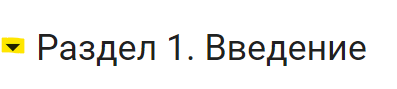

# Раздел 2. Работа с векторными данными в библиотеке Geopandas   

**Ссылка на техническую документацию Geopandas: https://geopandas.org/en/stable/**


*В этом разделе мы познакомимся с основами загрузки и обработки географических данных, в основном с помощью Geopandas:**

1. Для начала работы с Geopandas необходимо установить его и его зависимости. Это можно сделать с помощью менеджера пакетов Python, такого как pip. После установки Geopandas можно импортировать в свой проект и начать использовать его функциональность.

2. Для загрузки географических данных в Geopandas можно использовать различные источники, такие как файлы формата Shapefile, файлы формата GeoJSON, базы данных или непосредственно из веб-сервиса, такого как OpenStreetMap. Примеры кода для загрузки данных из этих источников доступны в [документации Geopandas](https://geopandas.org/en/stable/).

3. Одна из основных структур данных Geopandas - это GeodataFrame. Она является расширением Pandas DataFrame и содержит специальные столбцы, содержащие геометрическую информацию. Геометрическая информация представляется как объекты Shapely, которые могут содержать точки, линии, полигоны и другие геометрические сущности.

4. Операции манипуляции данными, доступные в Geopandas, включают сортировку, фильтрацию, группировку и слияние данных. Эти операции могут быть выполнены как на данных атрибутивной таблицы, так и на геометрических объектах. Также Geopandas предоставляет возможность проводить пространственные операции, такие как перекрытие, объединение, разделение и трансформация геометрических объектов.

5. Geopandas также обладает возможностью проекции географических данных. Она позволяет преобразовывать данные из одной системы координат в другую, что является важным для различных задач анализа и визуализации географических данных.

6. Визуализация географических данных в Geopandas осуществляется с помощью библиотеки Matplotlib. Метод plot() позволяет построить карты, графики и диаграммы на базе GeodataFrame/GeoSeries. Дополнительно можно настроить внешний вид карты, добавить легенду и масштаб, и сохранить результат в файл.

7. Geopandas также имеет возможность работать с временными данными. Это позволяет анализировать географические данные, учитывая их изменение с течением времени. Поддерживаемые операции со временем включают фильтрацию, группировку, агрегацию и визуализацию данных.

8. И, наконец, Geopandas интегрируется хорошо с другими библиотеками Python, такими как NumPy, SciPy, Rasterio и GDAL. Это позволяет использовать их функциональность в комбинации с Geopandas для выполнения более сложных задач геопространственного анализа и обработки данных.

> Это только обзор основных возможностей Geopandas. Для более глубокого понимания и использования всех функций и методов Geopandas рекомендуется прочитать документацию и изучить примеры кода.

### 2.1 Загрузка данных
Для загрузки географических данных в Geopandas можно использовать функцию **read_file()**, в качестве аргумента которой необходимо указать путь к файлу.

Geopandas может читать практически любой векторный формат пространственных данных, включая ESRI shapefile, GeoJSON и Geopackages.  


* Давайте еще раз посмотрим на наши данные:


In [ ]:
# См. данные.
!ls DATA

cities.geojson	      DeSO_region.gpkg-wal  GBGDEM_50m.tif.aux.xml  vastra.dbf	vastra.shp
DeSO_region.gpkg      GBGDEM_50m.tfw	    roads.geojson	    vastra.prj	vastra.shx
DeSO_region.gpkg-shm  GBGDEM_50m.tif	    vastra.cpg		    vastra.qpj


#### 2.1.1. Чтение данных

Код, написанный ниже, используется для чтения гео-данных из файла формата GeoPackage (расширение .gpkg). В данном случае, файл с именем 'DeSO_region.gpkg' располагается в папке с именем 'DATA'.

Импортируется библиотека geopandas (сокращенно gpd), которая позволяет работать с геоданными, а также другие необходимые библиотеки, такие как pandas и numpy.

Далее, функция read_file() из библиотеки geopandas вызывается с аргументом 'DATA/DeSO_region.gpkg', что указывает на путь к файлу, который нужно прочитать. Прочитанные данные сохраняются в переменной regions.

Исходя из имени файла ('DeSO_region.gpkg'), можно предположить, что это данные о регионах или областях, связанных с неким проектом или задачей. Эти данные могут содержать информацию о границах регионов, атрибутах и других географических свойствах, которые можно использовать для анализа или визуализации.

In [ ]:
# Открываем данные DeSO_region
regions = gpd.read_file('DATA/DeSO_region.gpkg')

In [ ]:
# Теперь, когда мы считали данные, давайте посмотрим первые 5 строк.
regions.head()

,Deso,Bef_201612,geometry
0,0115A0040,1433,"MULTIPOLYGON (((690301.503 6614909.754, 690301..."
1,0136A0010,746,"MULTIPOLYGON (((688731.626 6547758.133, 686809..."
2,0188A0150,1216,"MULTIPOLYGON (((699545.557 6645614.544, 699264..."
3,0188A0130,1246,"MULTIPOLYGON (((744992.280 6636197.581, 737578..."
4,0188A0060,2071,"MULTIPOLYGON (((755220.730 6620631.909, 746128..."


Таблица состоит из трёх столбцов: Deso, Bef_201612 и geometry.

* Столбец Deso содержит идентификаторы объектов (код района). Каждый объект имеет уникальный код, например, 0115A0040.

* Столбец Bef_201612 содержит числовые значения,  характеризующие численность населения в районе.

* Столбец geometry содержит геометрические данные в формате MULTIPOLYGON. MULTIPOLYGON - это тип геометрии, который описывает многоугольники или наборы многоугольников. В данной таблице каждая геометрическая фигура представлена в виде мультиполигона, то есть набора полигонов.

* Каждая строка в таблице представляет собой отдельный объект. Например, первая строка описывает объект с идентификатором 0115A0040, который имеет геометрическое представление в виде мультиполигона.

> Таким образом, таблица содержит информацию об объектах, их идентификаторы, числовые показатели и геометрическое представление в виде мультиполигонов.






#### 2.1.2. Статистический анализ данных

Метод regions.**describe()** выполняет статистический анализ описательных характеристик набора данных regions.

Метод **describe()** вызывается на объекте DataFrame (наборе данных) regions. Он возвращает сводку статистических показателей для числовых колонок в наборе данных.

Подробнее, метод describe() возвращает следующие статистические показатели:

- count: количество непропущенных значений в каждой колонке
- mean: среднее значение для каждой колонки
- std: стандартное отклонение для каждой колонки
- min: минимальное значение для каждой колонки
- 25%: первый квартиль (25%), значение, которое делит набор данных на 25% наименьших значений
- 50%: второй квартиль (50%), значение, которое делит набор данных на две равные части
- 75%: третий квартиль (75%), значение, которое делит набор данных на 25% наибольших значений
- max: максимальное значение для каждой колонки

Эти статистические показатели позволяют оценить распределение данных в каждой колонке, идентифицировать наличие выбросов и определить характеристики данных.

In [ ]:
# У нас есть три столбца. Deso - код района. Bef_201612 - численность населения в районе. Столбец geometry
#  (Объекты Geometry определяют пространственное положение и связанную с ним геометрическую форму.)
# Прежде чем что-то делать с данными, необходимо получить их описание, что легко сделать с помощью модуля describe().

regions.describe()

# Вы получаете представление о распределении данных, например, о максимальной и минимальной численности населения во всех регионах.

,Bef_201612
count,5985.000000
mean,1667.238429
std,407.551675
min,652.000000
25%,1377.000000
50%,1664.000000
75%,1953.000000
max,2691.000000


Параметр **shape** используется для получения информации о форме объекта. В данном случае, мы ожидаем, что объект regions имеет какие-то размеры или размерности.

* Возвращаемое значение параметра shape будет зависеть от типа объекта. Если объект является массивом или матрицей, то параметр вернет кортеж, в котором каждый элемент соответствует размерности массива.

* Например, если объект regions является двумерным массивом размера 3х4, то результатом вызова параметра shape будет (3, 4). Если же объект regions является одномерным массивом длины 5, то результатом будет (5,).

Результат может быть использован в дальнейшем коде для различных целей, например, для определения размеров, создания массивов или выполнения других операций.

In [ ]:
# Выведем размерность нашего датафрейма, с помощью метода .shape()

regions.shape # У нас есть 5985 строк и 3 столбца

(5985, 3)

В строке ниже приведен код для отображения географической информации на карте:

Функция `regions.plot()` вызывает plot метод на объекте `regions`, который представляет географические данные.

Метод `plot()` позволяет создать графическое представление географических данных, например, карту с определенным стилем и параметрами.

Подробности визуализации зависят от используемых параметров и настроек в коде, которые определены до вызова `regions.plot()`. Например, можно задать стиль карты, цвета областей, представить границы регионов, добавить перекрестные ссылки, заголовок и т.д.

<Axes: >

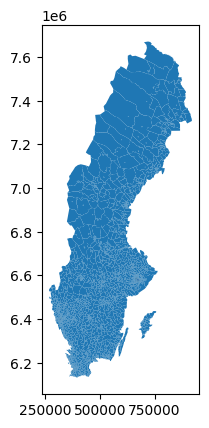

In [ ]:
# И теперь, мы можем легко строить карты с помощью метода .plot()
regions.plot()

Код `regions.crs` используется для получения информации о координатной системе (CRS) объекта геоданных `regions` в библиотеке Geopandas.

CRS - это способ представления и описания пространственных данных, определяющий способ преобразования координат для отображения данных на земной поверхности. CRS может быть определена в разных форматах, таких как EPSG код (например, EPSG:4326) или WKT (Well-Known Text).

Вызов `regions.crs` возвращает текущую CRS, которая была назначена объекту `regions`. Она может быть представлена в формате EPSG кода или строковом формате WKT.

Примеры значений, которые могут быть возвращены `regions.crs`:

- EPSG код: "EPSG:4326" (координатная система WGS84)
- WKT формат: "PROJCS["World_Mollweide",GEOGCS["GCS_WGS_1984",DATUM["WGS_1984",SPHEROID["WGS_1984",6378137.0,298.257223563]],PRIMEM["Greenwich",0.0],UNIT["Degree",0.0174532925199433]],PROJECTION["Mollweide"],PARAMETER["False_Easting",0.0],PARAMETER["False_Northing",0.0],PARAMETER["Central_Meridian",0.0],UNIT["Meter",1.0]]"

Использование `regions.crs` полезно, чтобы узнать, какая CRS была назначена геоданным, так как множество операций, таких как преобразование координат, визуализация и анализ данных, требуют правильного CRS для правильной интерпретации географического контекста и представления данных.

In [ ]:
# Для вывода информации об используемой системе координат, выведем значение параметра .crs
regions.crs

<Projected CRS: EPSG:3006>
Name: SWEREF99 TM
Axis Info [cartesian]:
- N[north]: Northing (metre)
- E[east]: Easting (metre)
Area of Use:
- name: Sweden - onshore and offshore.
- bounds: (10.03, 54.96, 24.17, 69.07)
Coordinate Operation:
- name: SWEREF99 TM
- method: Transverse Mercator
Datum: SWEREF99
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

#### Задание 2.1

1.   Прочитайте файл cities.geojson с помощью функции **read_file()**, которую мы использовали для считывания файла со списком регионов. Сохраните результат, возвращаемый этой функцией в переменную *cities*.
2.   Выведите на экран первые 5 строк  **.head()**.
3.   Получите анализ описательных характеристик набора данных **.describe**.
4.   Выведите количество строк и столбцов **.shape**
5.   Постройте карту городов **.plot**.
6.   Выведите данные о городах, обратившись к параметру **.crs**.



1.   Прочитайте файл cities.geojson с помощью функции **read_file()**, которую мы использовали для считывания файла со списком регионов. Сохраните результат, возвращаемый этой функцией в переменную *cities*.

In [ ]:
# 1. Прочитайте файл cities.geojson с помощью функции read_file(), которую мы использовали для регионов. Назовите его cities

cities = gpd.read_file('/content/DATA/cities.geojson')

2.   Выведите на экран первые 5 строк объекта cities **(.head())**.

In [ ]:
cities.head()

,osm_id,code,fclass,population,name,geometry
0,11094836,1002,town,29891,Nyköping,POINT (17.01181 58.75449)
1,15412058,1001,city,93838,Helsingborg,POINT (12.70407 56.04420)
2,20853389,1002,town,6497,Nykvarn,POINT (17.43124 59.17724)
3,20975576,1002,town,7418,Söderköping,POINT (16.32162 58.48238)
4,20975577,1002,town,2685,Valdemarsvik,POINT (16.60322 58.20259)


3.   Получите анализ описательных характеристик объекта cities **(.describe)**.

In [ ]:
cities.describe()

,code,population
count,314.000000,314.000000
mean,1001.945860,21357.550955
std,0.299518,60315.219283
min,1001.000000,0.000000
25%,1002.000000,3887.500000
50%,1002.000000,8258.500000
75%,1002.000000,18592.500000
max,1005.000000,829417.000000


4.   Выведите количество строк и столбцов объекта cities **(.shape)**


In [ ]:
cities.shape

(314, 6)

5.   Визуализируйте (постройте карту/график) объект cities (**.plot**)


<Axes: >

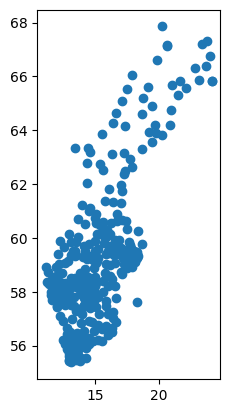

In [ ]:
cities.plot()

6.   Выведите  информацию о координатной системе (CRS) объекта геоданных cities **(.crs)**.


In [ ]:
cities.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

### 2.2 Географические системы координат (CRS)

Как видно, данные о городах и регионах имеют разные системы координат (СК). Поэтому в следующем подразделе мы рассмотрим референсные СК и проекции географических данных.

Фреймы геоданных имеют атрибут .crs, который позволяет получить исходные координаты, используемые в датафреймах. Эти координаты легко преобразовать и спроецировать.

Преобразуем датафрейм с городами в ту же СК, что и датафрейм с регионами - 'epsg:3006' Шведской системы координат. Перед этим посмотрим, что произойдет, если наложить города и регионы без перепроецирования.

Разбираться в коде визуализации сейчас не нужно (раздел "Визуализация геоданных" мы рассмотрим позже).

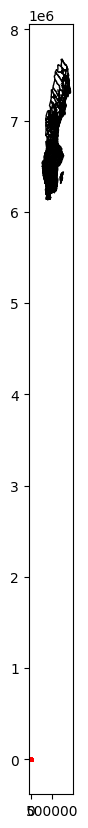

In [ ]:
fig, ax  = plt.subplots(figsize=(14,10))
ax.set_aspect('equal')

regions.plot(ax=ax, color='white', edgecolor='black')
cities.plot(ax=ax, marker = '*', color='red', markersize=5)
plt.show()

**Видно, что области не совпадают.**

Для перепроецирования в Geopandas можно использовать метод **.to_crs()**, указав наименование проекции. В данном случае мы будем использовать 'epsg:3006'

Код для преобразования геометрий городов из одной проекции в другую, используя библиотеку geopandas, представлен в блоке ниже.

Подробное описание принципа его работы:

1. `cities` - это геодатафрейм, содержащий геометрии городов в определенной проекции.
2. `to_crs()` - это метод геодатафрейма geopandas, который преобразует геометрии в новую проекцию.
3. `{'init': 'epsg:3006'}` - это аргумент метода `to_crs()`, который задает новую проекцию в формате EPSG.
4. `'epsg:3006'` - это код EPSG, который представляет проекцию с координатной системой SWEREF99TM, используемой в Швеции.

Таким образом, данный код преобразует геометрии городов, содержащиеся в геодатафрейме `cities`, в проекцию SWEREF99TM, заданную EPSG кодом 3006. Результатом будет новый геодатафрейм `cities_proj`, содержащий геометрии городов в новой проекции.

In [ ]:
cities_proj = cities.to_crs({'init': 'epsg:3006'})

/usr/local/lib/python3.10/dist-packages/pyproj/crs/crs.py:141: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)


* Теперь, когда мы изменили проекцию датафрейма с городами на 'EPSG:3006', всё выводится корректно.

* С этого момента следует помнить, что в дальнейшем мы будем использовать датафрейм **cities_proj**, вместо cities!

Визуализация:

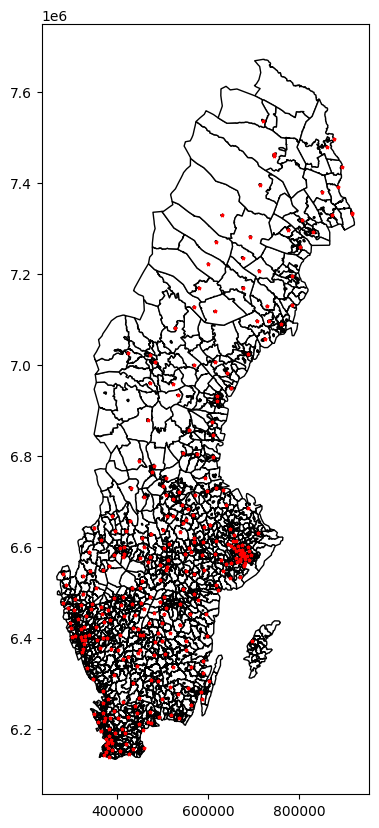

In [ ]:
fig, ax  = plt.subplots(figsize=(14,10))
ax.set_aspect('equal')
regions.plot(ax=ax, color='white', edgecolor='black')
cities_proj.plot(ax=ax, marker = '*', color='red', markersize=5)
plt.show()

### 2.3 Пространственное объединение

 * В данных о городах нет региона, а в наших данных о регионах с небольшими областями есть не названия регионов, а небольшие коды областей (вероятно, избирательные участки, данные взяты из Статистического управления Швеции).

 * Далее нам необходимо сформировать выборку, состоящую только из городов, находящихся в определенных регионах (например, в регионе Vastra-Götland (Вастра-Гётланд)). Если бы у нас был уникальный атрибут, общий для этих двух наборов данных (cities_proj и regions), то мы могли бы использовать атрибутное объединение, но у нас его нет, поэтому нам нужно отдельно загрузить shp-файлы с набором данных для региона Vastra-Götland, после чего выполнить пространственное объединение.

> К этому времени Вы уже знаете, как загружать геоданные с помощью **.read_file()**  Откроем шейп-файл vastra.shp и выполним то же самое исследование данных, которое мы проводили для городов и регионов. Назовем его **vastra**.

In [ ]:
vastra = gpd.read_file('DATA/vastra.shp')

In [ ]:
vastra.head()

,KKOD,KATEGORI,KOMMUNKOD,KOMMUNNAMN,LANSKOD,LANSNAMN,KOM_KOD,LAN_KOD,X_poly,Y_poly,X_lan_poly,Y_lan_poly,Y_lan_po_1,geometry
0,414,Kommun,1494,Lidk�ping,14,V�stra G�talands l�n,1494,14,385174.0,6492650.0,0.0,0,0.0,"POLYGON ((408887.450 6512813.931, 399589.973 6..."
1,414,Kommun,1427,Soten�s,14,V�stra G�talands l�n,1427,14,271235.0,6477930.0,0.0,0,0.0,"POLYGON ((294008.074 6486504.549, 293582.164 6..."
2,414,Kommun,1472,Tibro,14,V�stra G�talands l�n,1472,14,454587.0,6479200.0,0.0,0,0.0,"POLYGON ((461499.992 6491253.550, 461464.634 6..."
3,414,Kommun,1492,�m�l,14,V�stra G�talands l�n,1492,14,364344.0,6536910.0,0.0,0,0.0,"POLYGON ((378643.097 6521285.034, 378454.516 6..."
4,414,Kommun,1486,Str�mstad,14,V�stra G�talands l�n,1486,14,275764.0,6537670.0,0.0,0,0.0,"POLYGON ((295874.894 6533034.839, 295577.173 6..."


In [ ]:
vastra.shape

(51, 14)

In [ ]:
vastra.crs

<Projected CRS: EPSG:3006>
Name: SWEREF99 TM
Axis Info [cartesian]:
- N[north]: Northing (metre)
- E[east]: Easting (metre)
Area of Use:
- name: Sweden - onshore and offshore.
- bounds: (10.03, 54.96, 24.17, 69.07)
Coordinate Operation:
- name: SWEREF99 TM
- method: Transverse Mercator
Datum: SWEREF99
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

<Axes: >

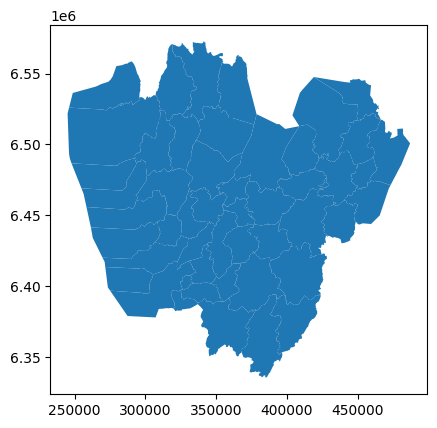

In [ ]:
vastra.plot()

Мы загрузили регион Vastra-Götland и теперь можем получить все города этого региона в Geopandas с помощью функции **gpd.sjoin()**, предоставив два набора данных: в нашем случае города и регион.  

Также необходимо указать способ объединения: inner, left, right (внутренний, левый, правый) и операцию геообработки: within, intersection, contain (внутри, пересечение, содержание) и т.д..

Поскольку мы хотим получить все города, входящие в регион, мы сделаем это следующим образом:

1. `gpd.sjoin` является функцией, предоставляемой GeoPandas для выполнения пространственного соединения.

2. `cities_proj` и `vastra` - это два GeoDataFrame объекта, которые мы хотим соединить на основе их геометрического положения.

3. Параметры `how="inner"` и `op='within'` указывают, что мы хотим выполнить внутренее соединение, то есть вернуть только те города, которые находятся внутри географической области Вастра (Vastra). Оператор `within` используется для определения, находится ли один объект полностью внутри другого объекта.

4. Результирующий GeoDataFrame с названием `vastra_cities` будет содержать только те города, которые находятся внутри географической области Вастракарла (Vastra).

In [ ]:
vastra_cities = gpd.sjoin(cities_proj, vastra, how="inner", op='within')

/usr/local/lib/python3.10/dist-packages/IPython/core/interactiveshell.py:3473: FutureWarning: The `op` parameter is deprecated and will be removed in a future release. Please use the `predicate` parameter instead.
  if (await self.run_code(code, result,  async_=asy)):
<ipython-input-28-afd7e04bf4ee>:1: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: +init=epsg:3006 +type=crs
Right CRS: EPSG:3006

  vastra_cities = gpd.sjoin(cities_proj, vastra, how="inner", op='within')


In [ ]:
vastra_cities.head()

,osm_id,code,fclass,population,name,geometry,index_right,KKOD,KATEGORI,KOMMUNKOD,KOMMUNNAMN,LANSKOD,LANSNAMN,KOM_KOD,LAN_KOD,X_poly,Y_poly,X_lan_poly,Y_lan_poly,Y_lan_po_1
6,21382663,1002,town,4928,Lilla Edet,POINT (330937.487 6447347.505),39,414,Kommun,1462,Lilla Edet,14,V�stra G�talands l�n,1462,14,331659.0,6447140.0,0.0,0,0.0
11,24970666,1002,town,8027,Tidaholm,POINT (438819.655 6449263.415),41,414,Kommun,1498,Tidaholm,14,V�stra G�talands l�n,1498,14,437889.0,6445560.0,0.0,0,0.0
13,25508588,1002,town,34466,Skövde,POINT (432438.212 6472694.463),24,414,Kommun,1496,Sk�vde,14,V�stra G�talands l�n,1496,14,436099.0,6476920.0,0.0,0,0.0
17,25710724,1002,town,3889,Vara,POINT (379927.452 6459575.461),13,414,Kommun,1470,Vara,14,V�stra G�talands l�n,1470,14,386131.0,6457600.0,0.0,0,0.0
24,25930131,1001,city,522259,Göteborg,POINT (319298.131 6400160.721),32,414,Kommun,1480,G�teborg,14,V�stra G�talands l�n,1480,14,307047.0,6395380.0,0.0,0,0.0


<Axes: >

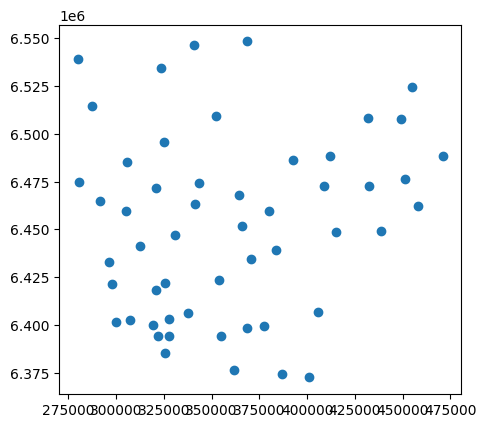

In [ ]:
# Все города этого региона
vastra_cities.plot()

Для того чтобы дополнительно выяснить, входит ли конкретный город в состав региона, можно использовать запрос с параметром **contain**.

* Рассмотрим это на примере города Гетеборн. Вначале нам нужно обратиться к соответствующему столбцу, в данном случае это столбец: 'name', а затем использовать логический оператор эквивалентности (равенства): '=='. Если имя найдено в таблице, то будет возвращена его строка, если нет, то ничего не будет возвращено:

* Код в блоке ниже используется для фильтрации данных в географическом датафрейме с использованием библиотеки Geopandas.

* Переменная "vastra_cities" является географическим датафреймом, содержащим информацию о городах региона.

* Код фильтрует этот датафрейм, проверяя условие "name == 'Göteborg'". Здесь 'name' - это столбец в датафрейме, содержащий имена городов.

* В итоге, код выбирает все строки в датафрейме "vastra_cities", где значение столбца "name" равно 'Göteborg'. Результат сохраняется в переменной "gothenburg".

> Таким образом, "gothenburg" будет содержать отфильтрованный географический датафрейм с информацией только о городе Гётеборг.

In [ ]:
gothenburg = vastra_cities[vastra_cities['name'] == 'Göteborg']
gothenburg

,osm_id,code,fclass,population,name,geometry,index_right,KKOD,KATEGORI,KOMMUNKOD,KOMMUNNAMN,LANSKOD,LANSNAMN,KOM_KOD,LAN_KOD,X_poly,Y_poly,X_lan_poly,Y_lan_poly,Y_lan_po_1
24,25930131,1001,city,522259,Göteborg,POINT (319298.131 6400160.721),32,414,Kommun,1480,G�teborg,14,V�stra G�talands l�n,1480,14,307047.0,6395380.0,0.0,0,0.0


#### Задание 2.2

Узнайте, является ли Borås городом в vastra_cities.

In [ ]:
boras = vastra_cities[vastra_cities['name'] == 'Borås']
boras

,osm_id,code,fclass,population,name,geometry,index_right,KKOD,KATEGORI,KOMMUNKOD,KOMMUNNAMN,LANSKOD,LANSNAMN,KOM_KOD,LAN_KOD,X_poly,Y_poly,X_lan_poly,Y_lan_poly,Y_lan_po_1
301,1643360977,1002,town,66273,Borås,POINT (377345.142 6399522.094),27,414,Kommun,1490,Bor�s,14,V�stra G�talands l�n,1490,14,377396.0,6400750.0,0.0,0,0.0


В Geopandas доступно множество операций геообработки, и прежде чем перейти к работе с растровыми данными с помощью библиотеки Rasterio, мы научимся делать буферизацию. Допустим, нам нужно получить буфер 100 или 500 метров вокруг города Гетеборга. Для этого вызвовем метод .buffer() и получим буфер вокруг точки:

<Axes: >

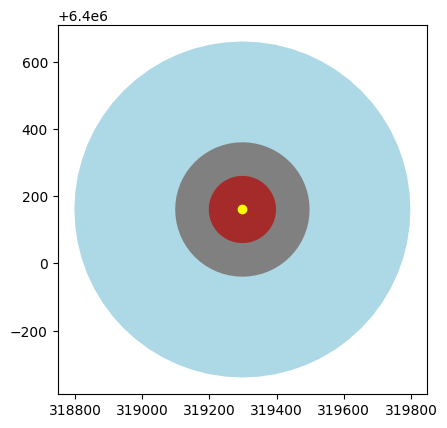

In [ ]:
goth_100 = gothenburg.buffer(100)
goth_200 = gothenburg.buffer(200)
goth_500 = gothenburg.buffer(500)
fig, ax = plt.subplots()
goth_500.plot(ax=ax, color='lightblue')
goth_200.plot(ax=ax, color='gray')
goth_100.plot(ax=ax, color='brown')
gothenburg.plot(ax=ax, color='Yellow')


#### Задание 2.3
Создайте буфер вокруг города Borås (Борос), укажите желаемый размер:

<Axes: >

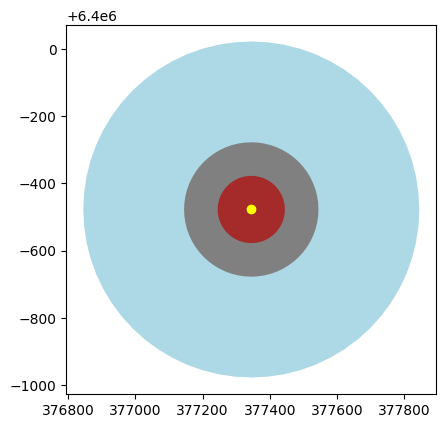

In [ ]:
bor_100 = boras.buffer(100)
bor_200 = boras.buffer(200)
bor_500 = boras.buffer(500)
fig, ax = plt.subplots()
bor_500.plot(ax=ax, color='lightblue')
bor_200.plot(ax=ax, color='gray')
bor_100.plot(ax=ax, color='brown')
boras.plot(ax=ax, color='Yellow')

# Раздел 3. Работа с растровыми данными в библиотеке RasterIO

**Ссылка на техническую документацию RasterIO: https://rasterio.readthedocs.io/en/latest/quickstart.html**

Библиотека RasterIO является инструментом для работы с растровыми данными в языке программирования Python. Она предоставляет удобный и эффективный интерфейс для чтения, записи и манипуляции растровыми изображениями.

Основные возможности RasterIO:

1. Чтение растровых данных: Библиотека позволяет открывать различные форматы файлов с растровыми данными, включая GeoTIFF, JPEG, PNG и др. Она поддерживает чтение как целых изображений, так и отдельных каналов (например, красного, зеленого и синего) в виде массивов NumPy.

2. Запись растровых данных: RasterIO позволяет создавать новые растровые изображения и записывать их в различные форматы файлов. Можно также изменять размер и глубину цвета изображения, а также применять различные фильтры и корректировки.

3. Манипуляции с данными: Библиотека предоставляет функции для работы с пикселями и пиксельными значениями, включая вычисление статистики (например, среднего и стандартного отклонения) и изменение значений пикселей на основе различных алгоритмов (например, контрастности и увеличения резкости).

4. Геопространственная поддержка: RasterIO обладает возможностями работы с географическими координатами и проекциями. Библиотека позволяет преобразовывать пиксельные координаты в географические и обратно, а также работать с информацией о пространственных координатах (например, системе координат и масштабе).

5. Многопоточность: RasterIO поддерживает параллельную обработку растровых данных, что позволяет ускорить выполнение операций на нескольких ядрах процессора. Это особенно полезно при работе с большими файлами или выполнении сложных операций надо множеством изображений.

6. Удобный интерфейс: Библиотека имеет интуитивно понятный и простой в использовании интерфейс. Она предоставляет множество функций и методов для работы с растровыми данными, а также документацию и примеры использования, что облегчает разработку и внедрение алгоритмов обработки растров.

> Подведя итог, RasterIO является мощным и полезным инструментом для работы с растровыми данными в Python. Библиотека обладает широкими возможностями чтения, записи и манипуляции изображениями, а также поддерживает работу с геопространственными данными. Она является отличным выбором для разработки геоинформационных систем, обработки спутниковых изображений, анализа и визуализации растровых данных.

In [ ]:
# Устанавливаем зависимости
import rasterio as rio
from rasterio.plot import show, show_hist
from rasterio.mask import mask
from rasterio import crs
from rasterio.warp import calculate_default_transform, reproject, Resampling
import matplotlib.pyplot as plt
import fiona

**Прочитаем растровый файл с цифровой моделью рельефа (ЦМР), который мы загрузили в самом начале, запустив код в блоке ниже:**

In [ ]:
dem = rio.open(r'DATA/GBGDEM_50m.tif') # Открытие растрового файла с помощью Rasterio
type(dem)

rasterio.io.DatasetReader

Подробное описание его работы:

* `rio.open(r'DATA/GBGDEM_50m.tif')` - эта строка открывает растровый файл с именем "GBGDEM_50m.tif" из директории "DATA" с помощью функции `rio.open()`. Переменная `dem`, после этого, содержит открытый растровый файл.

* `type(dem)` - эта строка выводит тип переменной `dem`.

* В данном случае она должна быть объектом типа `rasterio.io.DatasetReader`, что указывает на успешное открытие файла с помощью Rasterio.

**Отобразим сразу всю информацию о растровом снимке:**

In [ ]:
# Чтобы сразу отобразить сразу всю информацию о растровом снимке, вывыдем значение параметра .meta
dem.meta

{'driver': 'GTiff',
 'dtype': 'int32',
 'nodata': -2147483647.0,
 'width': 740,
 'height': 696,
 'count': 1,
 'crs': CRS.from_wkt('PROJCS["SWEREF99 TM",GEOGCS["SWEREF99",DATUM["SWEREF99",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6619"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",15],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]'),
 'transform': Affine(50.0, 0.0, 301475.0,
        0.0, -50.0, 6415775.0)}

`dem.meta` является объектом с метаданными растра, который представляет собой словарь. Метаданные растра включают информацию о его размере (ширина и высота), смещении (координаты верхнего левого угла), с учетом географической привязки, а также информацию о его проекции, типе данных и других свойствах.

Примеры ключей, которые могут присутствовать в словаре `dem.meta`, включают:
- `driver`: тип драйвера, который используется для чтения или записи данных растра (например, "GTiff" для GeoTIFF)
- `dtype`: тип данных пикселей в растре (например, "float32" или "int16")
- `width`: ширина растра в пикселях
- `height`: высота растра в пикселях
- `count`: количество каналов (например, 1 для одноканальных изображений или 3 для RGB изображений)
- `crs`: объект, описывающий пространственную привязку растра (например, систему координат или проекцию)
- `transform`: матрица преобразования, определяющая пространственное отображение пикселей на координаты (например, смещение и масштабирование)

**Далее рассмотрим пример вывода значений некоторых параметров по отдельности:**

* Получим информацию о проекции:

In [ ]:
dem.crs

CRS.from_wkt('PROJCS["SWEREF99 TM",GEOGCS["SWEREF99",DATUM["SWEREF99",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6619"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",15],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]')

* Отобразим количество пикселей по ширине растра:

In [ ]:
dem.width

740

* Отобразим количество пикселей по высоте растра:

In [ ]:
dem.height

696

* Выведем количество каналов:

In [ ]:
dem.count

1

## 3.1. Работа с растровыми и векторными данными

**Как визуализировать растровые данные с помощью rasterio?**

Поскольку ранее мы импортировали метод .show() из rasterio.plot, то можем использовать его напрямую:

1. `rasterio.plot.show` - это функция из библиотеки `rasterio.plot`, которая отображает растровое изображение.
2. `dem` - это переменная, содержащая растровое изображение, которое нужно отобразить.
3. `cmap='RdYlGn'` - это параметр функции, определяющий цветовую карту, используемую для отображения растра. В данном случае используется цветовая карта 'RdYlGn', которая представляет цвета в диапазоне от красного (Rd) до желтого (Yl) и зеленого (Gn).

Итак, результат выполнения этой строки кода будет отображение растра `dem` с использованием цветовой карты 'RdYlGn'.

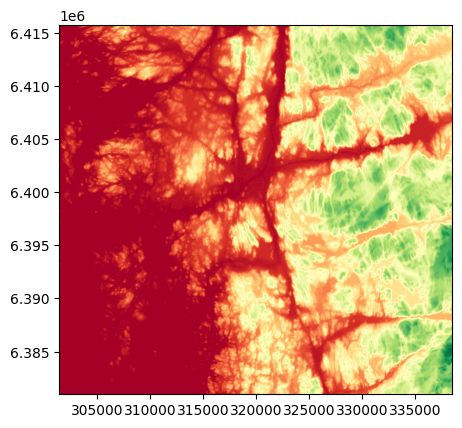

<Axes: >

In [ ]:
show(dem, cmap='RdYlGn')

**Выведем тот же снимок, но уже с другими параметрами отображения:**


* `cmap='terrain'` указывает цветовую карту, которая будет использоваться для отображения изображения. В данном случае, используется цветовая карта "terrain", которая обычно используется для отображения карты местности.

* `title='Gothenburg DEM'` задает заголовок для изображения. В данном случае, заголовок будет "Gothenburg DEM".

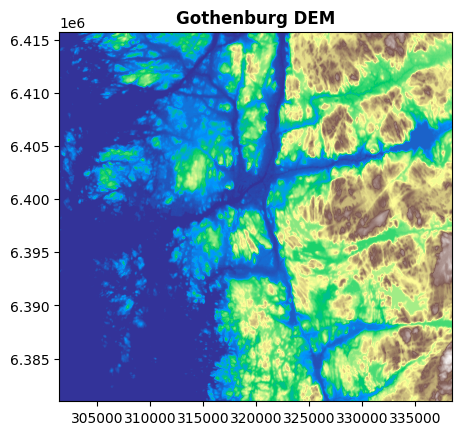

In [ ]:
show(dem, cmap='terrain', title='Gothenburg DEM')

plt.show()

**Сопоставим снимок с векторной картой региона:**


* В первой строке создается график с помощью функции subplots() из библиотеки matplotlib. Результат сохраняется в переменные fig и ax. fig представляет собой объект графика, а ax - объект осей, на которых будут отображаться данные.

* Во второй строке используется метод rasterio.plot.show() для отображения растрового изображения dem на графике. Параметр ax=ax указывает, что график должен быть отображен на тех же осях, которые были созданы в первой строке кода.

* В третьей строке используется функция plot() из библиотеки geopandas для отображения векторного слоя vastra на заданных осях ax (т.е. тех же осях, что и растровое изображение),  с прозрачностью 0.2.

> В результате выполнения этого кода будет показан график с отображением растрового и векторного слоев

<Axes: >

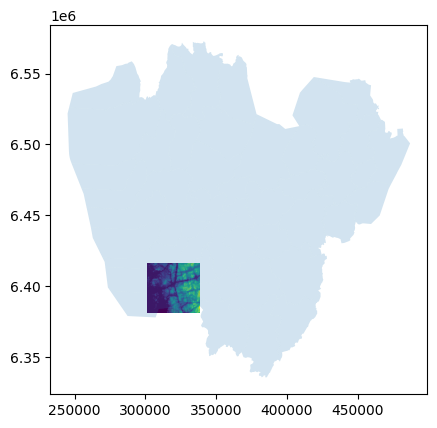

In [ ]:
fig, ax = plt.subplots()

show(dem, ax= ax)
vastra.plot(ax=ax, alpha=0.2)

**Теперь сопоставим снимок с векторным слоем конкретного города.**

Для этого выберем соответствующий элемент из датафрема vastra:

In [ ]:
vastra.head()

,KKOD,KATEGORI,KOMMUNKOD,KOMMUNNAMN,LANSKOD,LANSNAMN,KOM_KOD,LAN_KOD,X_poly,Y_poly,X_lan_poly,Y_lan_poly,Y_lan_po_1,geometry
0,414,Kommun,1494,Lidk�ping,14,V�stra G�talands l�n,1494,14,385174.0,6492650.0,0.0,0,0.0,"POLYGON ((408887.450 6512813.931, 399589.973 6..."
1,414,Kommun,1427,Soten�s,14,V�stra G�talands l�n,1427,14,271235.0,6477930.0,0.0,0,0.0,"POLYGON ((294008.074 6486504.549, 293582.164 6..."
2,414,Kommun,1472,Tibro,14,V�stra G�talands l�n,1472,14,454587.0,6479200.0,0.0,0,0.0,"POLYGON ((461499.992 6491253.550, 461464.634 6..."
3,414,Kommun,1492,�m�l,14,V�stra G�talands l�n,1492,14,364344.0,6536910.0,0.0,0,0.0,"POLYGON ((378643.097 6521285.034, 378454.516 6..."
4,414,Kommun,1486,Str�mstad,14,V�stra G�talands l�n,1486,14,275764.0,6537670.0,0.0,0,0.0,"POLYGON ((295874.894 6533034.839, 295577.173 6..."


**Обращаемся к элементу датафрейма и сохраняем его в отдельную переменную "gotheborg_polygon":**


In [ ]:
gotheborg_polygon = vastra[vastra.KOMMUNNAMN == 'G�teborg'] # (в столбце KOMMUNNAMN, получаем строку содержащую 'G�teborg')
gotheborg_polygon

,KKOD,KATEGORI,KOMMUNKOD,KOMMUNNAMN,LANSKOD,LANSNAMN,KOM_KOD,LAN_KOD,X_poly,Y_poly,X_lan_poly,Y_lan_poly,Y_lan_po_1,geometry
32,414,Kommun,1480,G�teborg,14,V�stra G�talands l�n,1480,14,307047.0,6395380.0,0.0,0,0.0,"POLYGON ((322858.598 6417170.611, 322404.301 6..."


* Первая строка кода создает новый объект типа GeoDataFrame с именем gotheborg_polygon. Этот объект будет содержать географический полигон города Гётеборг.

* Вторая строка кода использует метод индексации для выбора только тех строк в GeoDataFrame vastra, где значение в столбце KOMMUNNAMN (название муниципалитета) равно 'Göteborg'. Таким образом, мы выбираем только ту строку, которая представляет Гётеборг.

* Итак, в результате выполнения этого кода, переменная gotheborg_polygon будет содержать GeoDataFrame, состоящий только из одного полигона, представляющего границы муниципалитета Гётеборг.

**Отобразим сохраненный полигон:**


<Axes: >

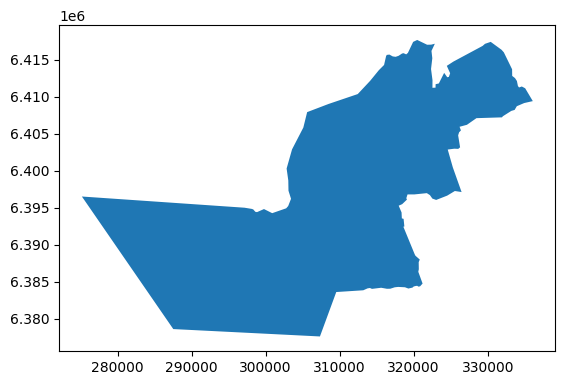

In [ ]:
gotheborg_polygon.plot()

**Сопоставим растр с полигоном:**


1. `fig, ax = plt.subplots()` - Создает новый объект фигуры и оси для отображения данных.

2. `show(dem, ax=ax)` - Отображает растровый файл `dem` с помощью функции `show()` из библиотеки RasterIO на созданной ранее оси `ax`.

3. `gotheborg_polygon.plot(ax=ax, alpha=0.3)` - Отображает полигон `gotheborg_polygon` на уже созданной оси `ax`. Функция `plot()` из библиотеки Geopandas используется для визуализации векторных данных. `alpha=0.3` устанавливает прозрачность полигона на 0.3.

<Axes: >

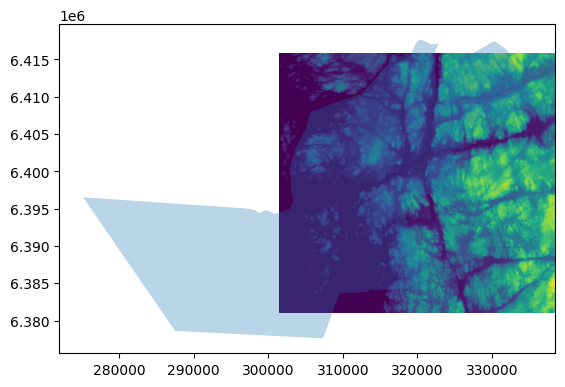

In [ ]:
fig, ax = plt.subplots()
show(dem, ax= ax)
gotheborg_polygon.plot(ax=ax, alpha=0.3)

**Далее сохраним только ту часть растра, которая входит в границы региона. Для этого необходимо сформировать список со всеми объектами полигона.**  

Удобным способом является реализация с использованием генератора списков (list comprehension):


In [ ]:
vector_geoms = [feature for feature in gotheborg_polygon.geometry]
vector_geoms

[<POLYGON ((322858.598 6417170.611, 322404.301 6416201.242, 322516.135 641521...>]

Дальнейшие шаги:

1. `with rio.open(r'DATA/GBGDEM_50m.tif') as src:` - открываем растровый файл 'DATA/GBGDEM_50m.tif' с помощью библиотеки rasterio и присваиваем его переменной src. Контекстное управление (конструкция `with`) гарантирует, что файл будет закрыт после выполнения блока кода.

2. `out_image, out_transform = rio.mask.mask(src, vector_geoms, crop=True)` - вызываем функцию mask из библиотеки rasterio для обрезки растровых данных в соответствии с геометрией, заданной векторными областями (vector_geoms). Результатом являются out_image (обрезанное изображение) и out_transform (содержащая информацию о преобразовании координат).

3. `out_meta = src.meta.copy()` - копируем метаданные исходного растрового файла src в переменную out_meta.

4. `out_meta.update({"driver": "GTiff", "height": out_image.shape[1], "width": out_image.shape[2], "transform": out_transform})` - обновляет метаданные из переменной out_meta, добавляя информацию о формате, высоте и ширине изображения, а также преобразовании координат.

5. `with rio.open("masked_raster.tif", "w", **out_meta) as dest:` - создаем новый растровый файл "masked_raster.tif" для записи с помощью библиотеки rasterio и присваиваем его переменной dest.

6. `dest.write(out_image)` - записываем обрезанное изображение out_image в файл dest (masked_raster.tif).

In [ ]:
with rio.open(r'DATA/GBGDEM_50m.tif') as src:
    out_image, out_transform = rio.mask.mask(src, vector_geoms,
                                                        crop=True)
    out_meta = src.meta.copy()

out_meta.update({"driver": "GTiff",
                 "height": out_image.shape[1],
                 "width": out_image.shape[2],
                 "transform": out_transform})
with rio.open("masked_raster.tif", "w", **out_meta) as dest:
    dest.write(out_image)

Мы сохранили нашу новую ЦМР, обрезанную до соответствующего полигона (г. Готенбург). Теперь отобразим её. (Она сохранена в корневой папки временного хранилища)

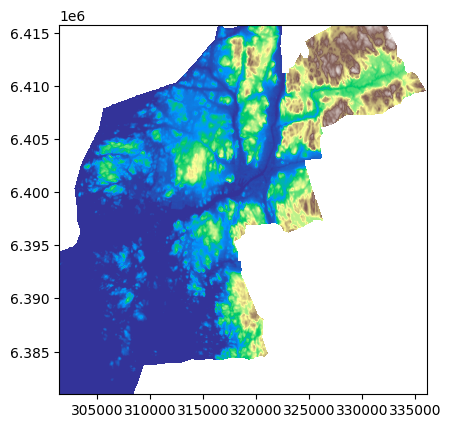

<Axes: >

In [ ]:
masked = rio.open('masked_raster.tif')
show(masked, cmap='terrain')

## 3.2. Работа с многоканальными растрами. Расчёт NDVI

* Считывать растровые изображения, с помощью библиотеки RasterIO, можно не только из локального хранилища, но и напрямую из сети Интернет.

* Для примера, рассмотрим фрагменты набора данных спектрорадиометра визуализации среднего разрешения (MODIS), представляющие собой несколько каналов одного снимка.

**Источник:** https://docs.opendata.aws/modis-pds/readme.html


Переменные `url_b1`, `url_b2` и `url_b3` содержат URL-адреса трех изображений с различными каналами (B01, B02 и B03) в серии данных MODIS. Каждый из URL-адресов ссылается на конкретное изображение в облаке Amazon S3.

Затем переменные `b1`, `b2` и `b3` создаются и используются для открытия соответствующих изображений с использованием функции `rio.open()`. Функция `rio.open()` принимает путь к изображению в качестве аргумента и возвращает объект типа `DatasetReader`, который предоставляет доступ к данным и метаданным изображения.

Наконец, функция `show()` используется для отображения каждого изображения. Функция `show()` принимает объект `DatasetReader` в качестве аргумента и отображает содержимое изображения.

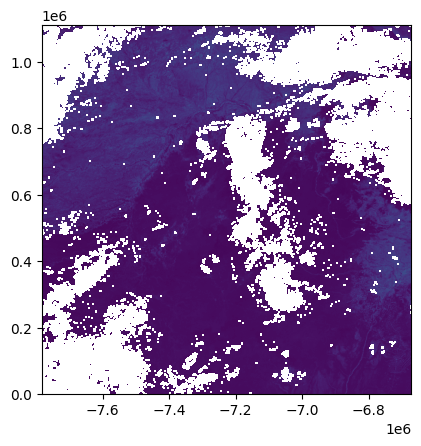

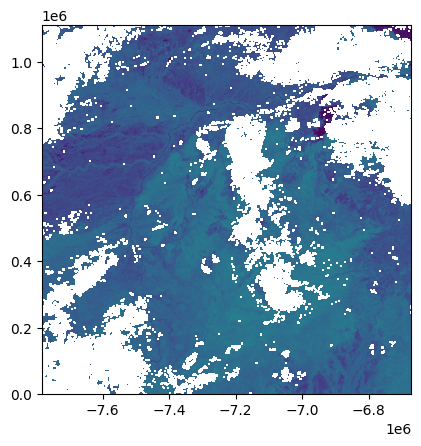

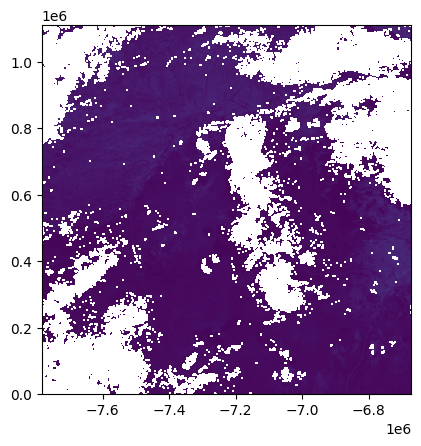

<Axes: >

In [ ]:
url_b1 = 'https://modis-pds.s3.amazonaws.com/MCD43A4.006/11/08/2019059/MCD43A4.A2019059.h11v08.006.2019072203257_B01.TIF'
url_b2 = 'https://modis-pds.s3.amazonaws.com/MCD43A4.006/11/08/2019059/MCD43A4.A2019059.h11v08.006.2019072203257_B02.TIF'
url_b3 = 'https://modis-pds.s3.amazonaws.com/MCD43A4.006/11/08/2019059/MCD43A4.A2019059.h11v08.006.2019072203257_B03.TIF'

b1 = rio.open(url_b1)
show(b1)
b2 = rio.open(url_b2)
show(b2)
b3 = rio.open(url_b3)
show(b3)


**Для загрузки данных в локальное хранилище используем следующий набор команд:**

1. `for i in range(1, 8):` - Цикл выполняется 7 раз, начиная с 1 и заканчивая 7. Значение `i` будет использоваться для вставки в URL, чтобы получить ссылки на разные файлы снимков MODIS.

2. `!wget -P MODIS_bands/ https://modis-pds.s3.amazonaws.com/MCD43A4.006/11/08/2019059/MCD43A4.A2019059.h11v08.006.2019072203257_B0{i}.TIF` - Это команда wget, которая загружает файлы снимков MODIS. Загруженные файлы будут сохранены в папке MODIS_bands. В URL используется переменная `i`, чтобы вставить разные значения в название файла. Файлы имеют расширение TIF.

Каждую итерацию цикла будет загружен файл снимка MODIS с соответствующим номером канала (от B01 до B07). В результате будут сохранены 7 файлов из набора MODIS в папке MODIS_bands.

In [ ]:
for i in range(1, 8):
  !wget -P MODIS_bands/ https://modis-pds.s3.amazonaws.com/MCD43A4.006/11/08/2019059/MCD43A4.A2019059.h11v08.006.2019072203257_B0{i}.TIF


--2024-06-06 12:00:51--  https://modis-pds.s3.amazonaws.com/MCD43A4.006/11/08/2019059/MCD43A4.A2019059.h11v08.006.2019072203257_B01.TIF
Resolving modis-pds.s3.amazonaws.com (modis-pds.s3.amazonaws.com)... 52.92.186.225, 52.92.205.129, 52.92.213.137, ...
Connecting to modis-pds.s3.amazonaws.com (modis-pds.s3.amazonaws.com)|52.92.186.225|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 7575886 (7.2M) [binary/octet-stream]
Saving to: ‘MODIS_bands/MCD43A4.A2019059.h11v08.006.2019072203257_B01.TIF.2’

MCD43A4.A2019059.h1 100%[===================>]   7.22M  4.73MB/s    in 1.5s    

2024-06-06 12:00:54 (4.73 MB/s) - ‘MODIS_bands/MCD43A4.A2019059.h11v08.006.2019072203257_B01.TIF.2’ saved [7575886/7575886]

--2024-06-06 12:00:54--  https://modis-pds.s3.amazonaws.com/MCD43A4.006/11/08/2019059/MCD43A4.A2019059.h11v08.006.2019072203257_B02.TIF
Resolving modis-pds.s3.amazonaws.com (modis-pds.s3.amazonaws.com)... 52.92.186.225, 52.92.205.129, 52.92.213.137, ...
Connecting to

**Сформируем одно многоканальное растровое изображение, написав для этого соответствующую функцию:**

Данный код выполняет функцию объединения всех растровых изображения в одно многоканальное растровое изображение.

1. В начале функции определяются параметры поиска растровых изображений по указанному пути и с заданным шаблоном имени файла, а также полное имя конечного файла (путь по умолчанию - "/content", шаблон имени файла по умолчанию - "*.TIF", полное имя конечного файла 'stack.tif').
2. Создается переменная `q`, в которую записывается результат объединения пути и шаблона для поиска файлов.
3. Вызывается функция `glob.glob()`, которая возвращает отсортированный список с путями к найденным файлам, соответствующим указанным критериям.
4. Копируется список путей в переменную `file_list` для дальнейшего использования.
5. Открывается первый файл из списка `file_list` с помощью `rio.open()` и создается объект `src0`.
6. Получается значение метаданных (`meta`) из `src0`.
7. Обновляется значение `count` в метаданных `meta` на количество файлов в списке `file_list`.
8. Открывается новый файл с именем 'stack.tif' в режиме записи с помощью `rio.open()`. Для этого используется параметр `**meta`, который распаковывает значения из словаря `meta` и передает их в функцию `open()`.
9. Далее выполняется цикл, в котором перечисляются итераторы `id` и `layer` из `enumerate(file_list, start=1)`.
    - Итератор `id` увеличивается на 1 при каждой итерации цикла.
    - Каждый итератор `layer` получает путь к файлу из списка `file_list`.
    - Файл `layer` открывается в режиме чтения с помощью `rio.open()` и создается объект `src1`.
    - Из объекта `src1` считывается первый канал (`src1.read(1)`) и он записывается в созданный ранее объект `dst` с помощью метода `write_band()` с номером канала `id` из итератора.
10. Код выполняется до завершения цикла и создания многоканального растрового изображения 'stack.tif'.

In [ ]:
def stack_band(dir_path = "/content", search_criteria = "*.TIF", save_path = 'stack.TIF'):

    #  Формируем список путей из каталога dir_path к файлам,
    # которые оканчиваются на search_criteria
    q = os.path.join(dir_path, search_criteria)
    paths_list = sorted(glob.glob(q))
    file_list = paths_list

    # Чтение метаданных первого файла
    with rio.open(file_list[0]) as src0:
        meta = src0.meta

    # Обновление значения параметра, отвечающего за количество слоёв в метаданных
    meta.update(count = len(file_list))

    # Считывание каждого слоя и запись его в стек
    with rio.open(save_path, 'w', **meta) as dst:
        for id, layer in enumerate(file_list, start=1):
            with rio.open(layer) as src1:
                dst.write_band(id, src1.read(1))

**Вызовем функцию для формрования многоканального изображения:**

In [ ]:
import os
stack_band("/content/MODIS_bands", "*.TIF", 'stack_bands.TIF')

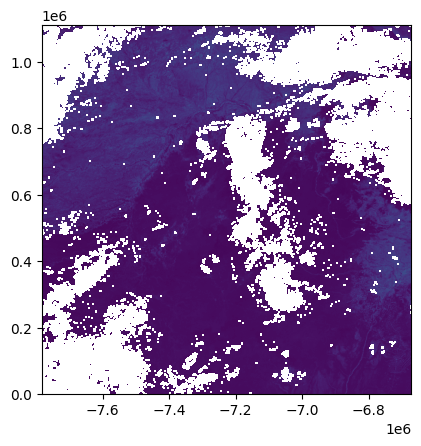

<Axes: >

In [ ]:
image_merge = rio.open('/content/stack_bands.TIF')
show(image_merge)

In [ ]:
image_merge.meta

{'driver': 'GTiff',
 'dtype': 'int16',
 'nodata': 32767.0,
 'width': 2400,
 'height': 2400,
 'count': 7,
 'crs': CRS.from_wkt('PROJCS["unnamed",GEOGCS["Unknown datum based upon the custom spheroid",DATUM["Not specified (based on custom spheroid)",SPHEROID["Custom spheroid",6371007.181,0]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Sinusoidal"],PARAMETER["longitude_of_center",0],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]'),
 'transform': Affine(463.3127165279169, 0.0, -7783653.637667,
        0.0, -463.3127165279167, 1111950.519667)}

**Рассмотрим отдельно некоторые каналов:**

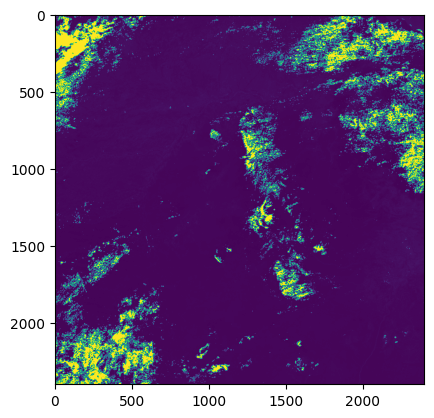

<Axes: >

In [ ]:
show(image_merge.read(4)) # Визуализируем 4 канал

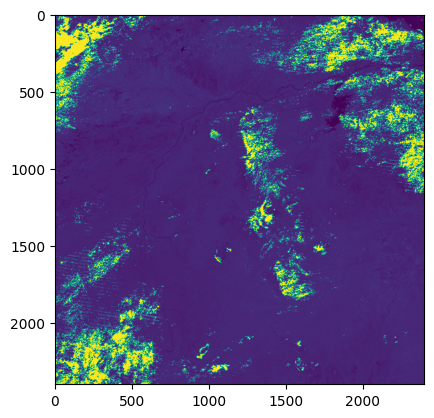

<Axes: >

In [ ]:
show(image_merge.read(5)) # Визуализируем 5 канал

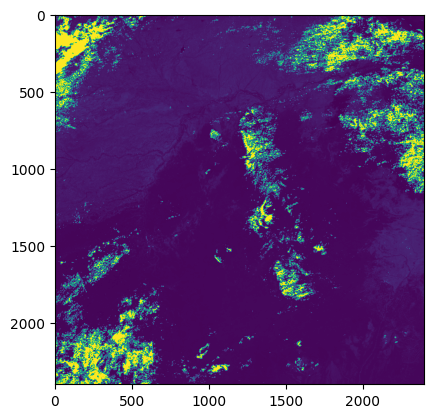

<Axes: >

In [ ]:
show(image_merge.read(7)) # Визуализируем 7 канал

Отобразим первые три канала более наглядно:

1. Создадим объект `fig` класса `Figure` размером 10х10 дюймов, который будет представлять графическую фигуру (холст) для отображения изображений.
2. Далее создается первый подграфик `ax1` с помощью метода `add_subplot()` класса `Figure`. Параметры `2,2,1` указывают на то, что холст будет разделен на сетку 2х2 и данный подграфик будет размещен в первой ячейке.
3. На этом подграфике вызывается метод `imshow()` для отображения значений из первого канала растрового изображения, полученного из переменной `image_merge`. Картой цветов для отображения используется 'terrain' (рельефная карта).
4. Создается второй подграфик `ax2` аналогичным образом, но отображается уже второй канал растрового изображения.
5. Создается третий подграфик `ax3` аналогичным образом для отображения третьего канала растрового изображения.

Таким образом, код в блоке ниже создает "холст" сеткой из трех подграфиков и отображает на каждом подграфике отдельный канал растрового изображения в виде карты цветов 'terrain'.

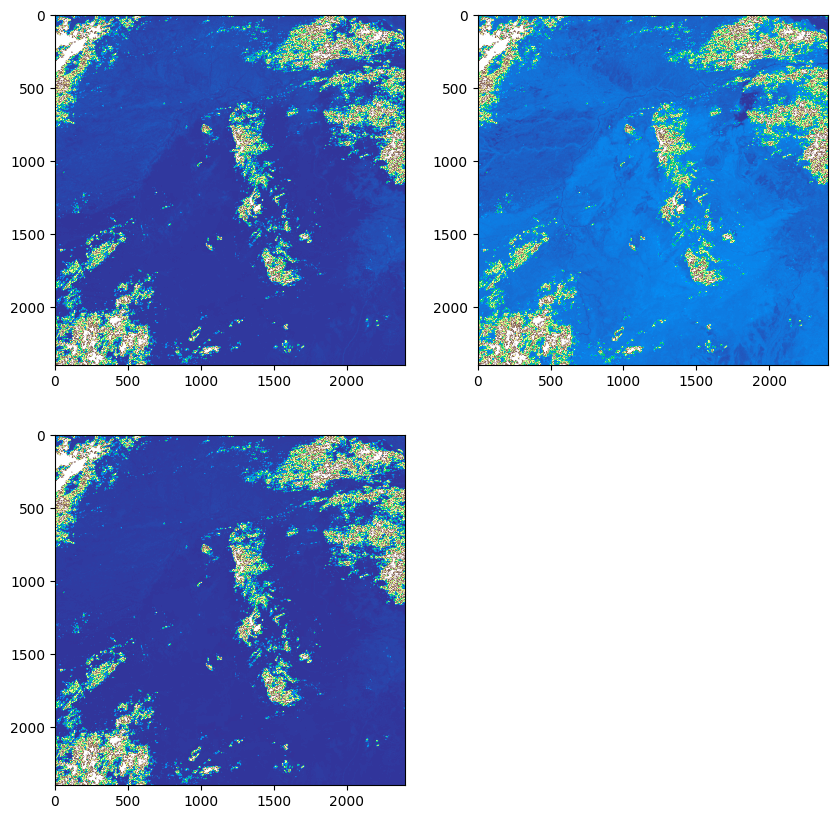

In [ ]:
fig = plt.figure(figsize=(10,10))
ax1 = fig.add_subplot(2,2,1)
ax1.imshow(image_merge.read(1), cmap='terrain')
ax2 = fig.add_subplot(2,2,2)
ax2.imshow(image_merge.read(2), cmap='terrain')
ax3 = fig.add_subplot(2,2,3)
ax3.imshow(image_merge.read(3), cmap='terrain')

**Построим гистограмму значений пикселей в каждом канале:**

Этот код использует функцию `show_hist` из библиотеки Rasterio, которая отображает гистограмму значений пикселей изображения.

Аргумент `image_merge` представляет собой массив значений пикселей или объект `DatasetReader` (читатель набора данных), содержащий растровое изображение, для которого необходимо построить гистограмму.

Аргумент `bins` определяет количество интервалов, на которые будет разделена гистограмма. В данном случае гистограмма будет иметь 50 интервалов.

Аргумент `histtype` определяет тип гистограммы. В данном случае используется `stepfilled`, что означает, что гистограмма будет представлена в виде ступенчатой линии с заливкой между ступеньками.

Аргумент `lw` определяет толщину линий гистограммы. В данном случае используется значение 0.0, что означает, что линии будут невидимыми.

Аргумент `stacked` определяет, являются ли столбцы гистограммы стековыми. Если установлено значение `True`, то столбцы будут накладываться друг на друга. В данном случае используется значение `False`, что означает, что каждый столбец гистограммы будет отображаться отдельно.

Аргумент `alpha` определяет прозрачность гистограммы (от 0 до 1). В данном случае используется значение 0.3, что означает, что гистограмма будет отображаться с низкой прозрачностью.

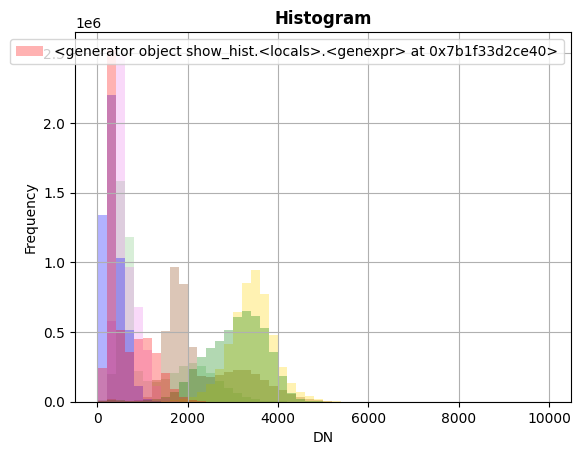

In [ ]:
rio.plot.show_hist(image_merge, bins=50, histtype='stepfilled', lw=0.0, stacked=False, alpha=0.3)

**Приступим к расчету индекса NDVI**

* Нормализированный вегетационный индекс (NDVI) - это стандартизированный индекс, показывающий наличие и состояние растительности (относительную биомассу).
> NDVI = (NIR-Red)/(NIR+Red)

**Предположим, что в нашем случае Канал 1 - красный (Red), а канал 2 - инфракрасный (NIR):**

1. `img = image_merge.read()` - Функция `read()` используется для чтения данных из растрового файла `image_merge`. В данном случае, `image_merge` предполагается, что это растровый файл, из которого будут считаны данные.

2. `red  = img[0]` - Переменная `red` будет содержать первый канал (красный) из массива `img`.

3. `nir  = img[1]` - Переменная `nir` будет содержать второй канал (ближний инфракрасный) из массива `img`.

4. `ndvi = (nir - red) / (nir + red)` - Вычисление индекса нормализированных разностей растительности (NDVI) путем вычитания значения пикселя красного канала из значения пикселя ближнего инфракрасного канала и деления на сумму этих значений. Результат сохраняется в переменную `ndvi`.

5. `plt.imshow(ndvi, cmap='viridis')` - Функция `imshow()` из библиотеки `matplotlib.pyplot` используется для отображения массива `ndvi` в виде изображения. `cmap='viridis'` указывает цветовую карту (цветовой набор), в данном случае используется "viridis".

6. `plt.colorbar()` - Функция `colorbar()` из библиотеки `matplotlib.pyplot` добавляет цветовую шкалу к изображению. Цветовая шкала позволяет интерпретировать значения на изображении.

**Обратим внимание, что данная реализация не учитывает вероятное деление на ноль, вследствие чего может возникнуть ошибка!**

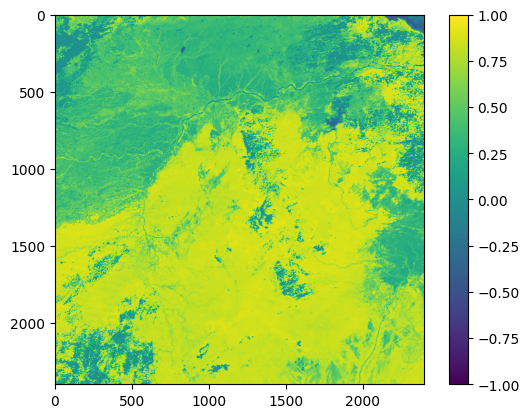

In [ ]:
img = image_merge.read()

red  = img[0]
nir  = img[1]
ndvi = (nir - red) / (nir + red)

plt.imshow(ndvi, cmap='viridis')
plt.colorbar()

**Реализуем оптимальный алгоритм с помощью математической библиотеки numpy:**

1. Первым делом импортируем numpy для работы с числовыми массивами.
2. Вычисляем индекс NDVI (Normalized Difference Vegetation Index) путем вычитания красного канала из инфракрасного канала и деления на сумму этих двух каналов.
3. С помощью функции np.nan_to_num(), все значения NaN в массиве NDVI заменяются на -1.
4. Используя функцию plt.imshow(), строится цветная картинка, представляющая NDVI, с использованием цветовой схемы 'viridis'.
5. С помощью функции plt.colorbar() добавляется шкала цветов для картинки.

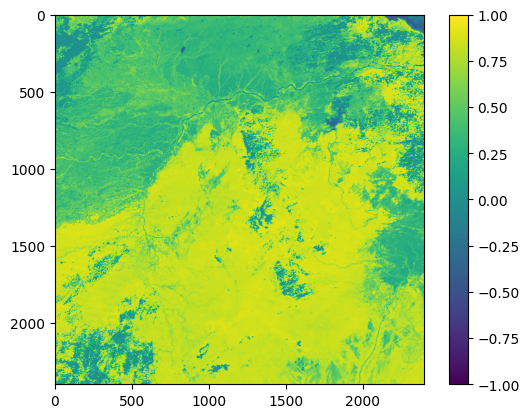

In [ ]:
import numpy as np

ndvi = np.divide(np.subtract(nir, red), np.add(nir, red))
ndvi = np.nan_to_num(ndvi, nan=-1)

plt.imshow(ndvi, cmap='viridis')
plt.colorbar()

### Задание 3.1. Визуализируйте фрагменты набора данных по ссылкам:

Канал №1. 'https://modis-pds.s3.amazonaws.com/MCD43A4.006/31/11/2017158/MCD43A4.A2017158.h31v11.006.2017171203421_B01.TIF'


Канал №5. 'https://modis-pds.s3.amazonaws.com/MCD43A4.006/31/11/2017158/MCD43A4.A2017158.h31v11.006.2017171203421_B05.TIF'

Канал №6. 'https://modis-pds.s3.amazonaws.com/MCD43A4.006/31/11/2017158/MCD43A4.A2017158.h31v11.006.2017171203421_B06.TIF'

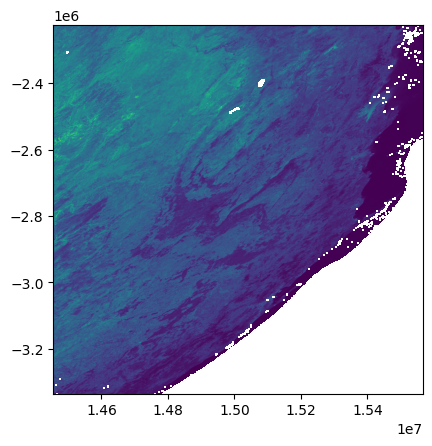

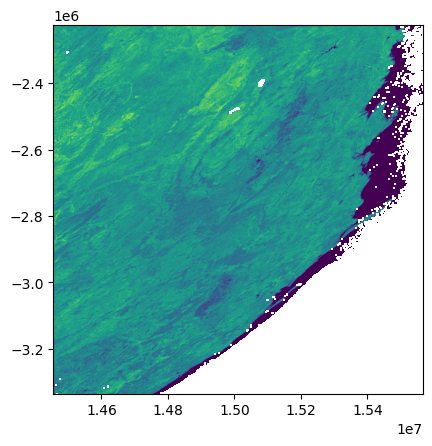

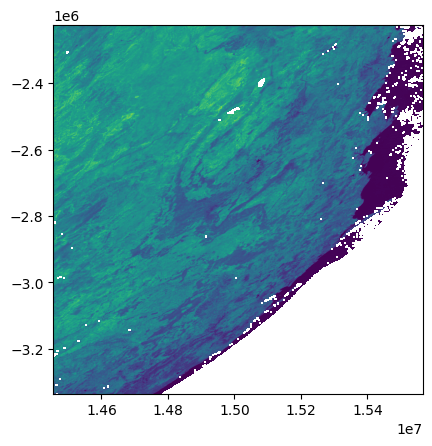

<Axes: >

In [ ]:
url_b1 = 'https://modis-pds.s3.amazonaws.com/MCD43A4.006/31/11/2017158/MCD43A4.A2017158.h31v11.006.2017171203421_B01.TIF'
url_b2 = 'https://modis-pds.s3.amazonaws.com/MCD43A4.006/31/11/2017158/MCD43A4.A2017158.h31v11.006.2017171203421_B05.TIF'
url_b3 = 'https://modis-pds.s3.amazonaws.com/MCD43A4.006/31/11/2017158/MCD43A4.A2017158.h31v11.006.2017171203421_B06.TIF'

b1 = rio.open(url_b1)
show(b1)
b2 = rio.open(url_b2)
show(b2)
b3 = rio.open(url_b3)
show(b3)

### Задание 3.2. Загрузите в локальное хранилище пять каналов рассматриваемого снимка:

(Ссылки на файлы заканчиваются на подстроку _B0*.TIF, где * - номер канала)

In [ ]:
for i in range(1, 6):
  !wget -P MODIS_bands/Practice https://modis-pds.s3.amazonaws.com/MCD43A4.006/31/11/2017158/MCD43A4.A2017158.h31v11.006.2017171203421_B0{i}.TIF

--2024-06-06 12:01:28--  https://modis-pds.s3.amazonaws.com/MCD43A4.006/31/11/2017158/MCD43A4.A2017158.h31v11.006.2017171203421_B01.TIF
Resolving modis-pds.s3.amazonaws.com (modis-pds.s3.amazonaws.com)... 52.218.250.115, 52.92.233.225, 52.92.149.113, ...
Connecting to modis-pds.s3.amazonaws.com (modis-pds.s3.amazonaws.com)|52.218.250.115|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 6345056 (6.1M) [binary/octet-stream]
Saving to: ‘MODIS_bands/Practice/MCD43A4.A2017158.h31v11.006.2017171203421_B01.TIF.2’

MCD43A4.A2017158.h3 100%[===================>]   6.05M  4.37MB/s    in 1.4s    

2024-06-06 12:01:30 (4.37 MB/s) - ‘MODIS_bands/Practice/MCD43A4.A2017158.h31v11.006.2017171203421_B01.TIF.2’ saved [6345056/6345056]

--2024-06-06 12:01:30--  https://modis-pds.s3.amazonaws.com/MCD43A4.006/31/11/2017158/MCD43A4.A2017158.h31v11.006.2017171203421_B02.TIF
Resolving modis-pds.s3.amazonaws.com (modis-pds.s3.amazonaws.com)... 52.218.250.115, 52.92.233.225, 52.92.149.1

### Задание 3.3. Сформируйте из них одно многоканальное растровое изображение:

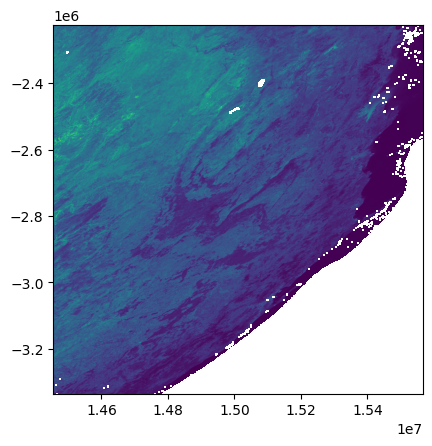

<Axes: >

In [ ]:
stack_band("/content/MODIS_bands/Practice", "*.TIF", 'stack_bands2.TIF')
image_merge2 = rio.open('/content/stack_bands2.TIF')
show(image_merge2)

### Задание 3.4. Построим гистограмму значений пикселей в каждом канале:

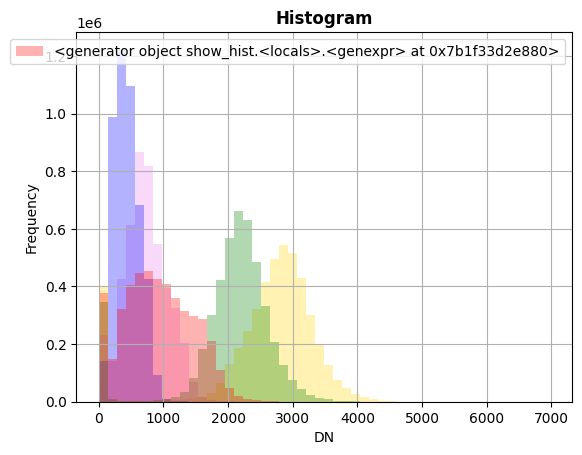

In [ ]:
rio.plot.show_hist(image_merge2, bins=50, histtype='stepfilled', lw=0.0, stacked=False, alpha=0.3)

### Задание 3.5. Расчитайте индекс NDVI:

<ipython-input-255-e5e1cc15cca6>:5: RuntimeWarning:

invalid value encountered in divide



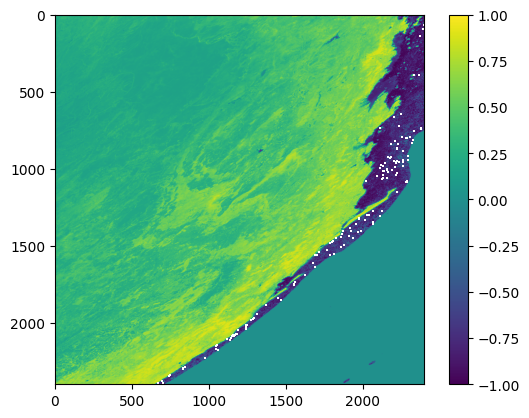

In [ ]:
img = image_merge2.read()

red  = img[0]
nir  = img[1]
ndvi = (nir - red) / (nir + red)

plt.imshow(ndvi, cmap='viridis')
plt.colorbar()

# Раздел 4. Визуализация геоданных

## 4.1. Статические карты

Мы создадим статическую карту более мелких областей, входящих в регион vastra. Перед этим нам необходимо расформировать границу области vastra и получить все более мелкие области, находящиеся в этой границе

In [ ]:
Vastra_BB = vastra.dissolve(by='KATEGORI')

<Axes: >

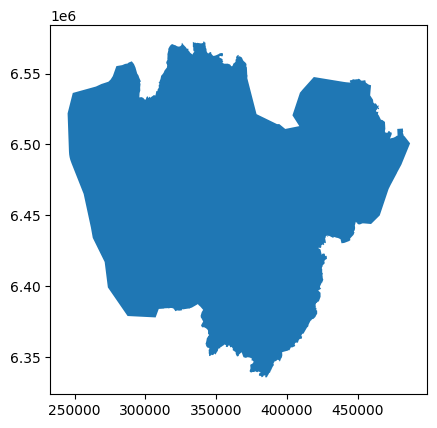

In [ ]:
Vastra_BB.plot()

In [ ]:
# Пусть внутри региона Вастра будут небольшие районы
vastra_areas = gpd.sjoin(regions, Vastra_BB, how="inner", op='within')

/usr/local/lib/python3.10/dist-packages/IPython/core/interactiveshell.py:3473: FutureWarning:

The `op` parameter is deprecated and will be removed in a future release. Please use the `predicate` parameter instead.



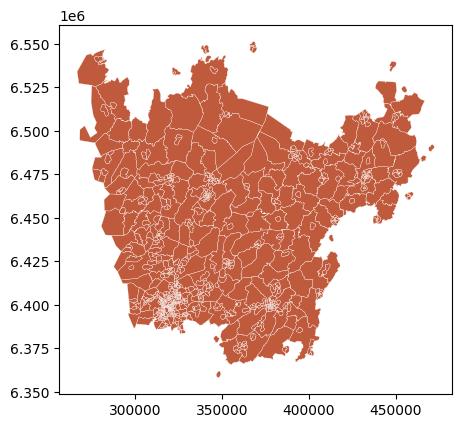

In [ ]:
vastra_areas.plot(facecolor='#D8A493', edgecolor='white', linewidth=0.2 , color='#C05A3C')
plt.show()

Выделим города и мелкие районы региона Вастра.

<Axes: >

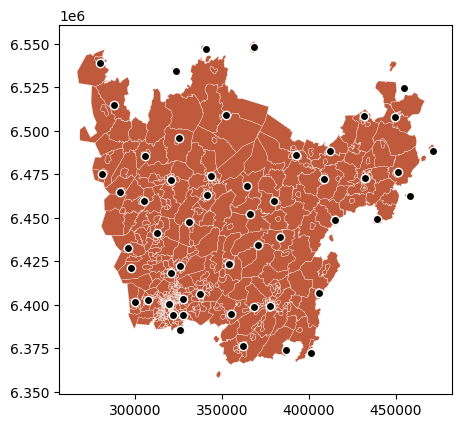

In [ ]:
fig, ax = plt.subplots()
vastra_areas.plot(ax=ax, facecolor='#D8A493', edgecolor='white', linewidth=0.2 , color='#C05A3C')
vastra_cities.plot(ax=ax, color='black', edgecolor='white')


Сформируем тематическую карту населения на небольших территориях, для этого необходимо указать столбец и схему классификации.

<Axes: >

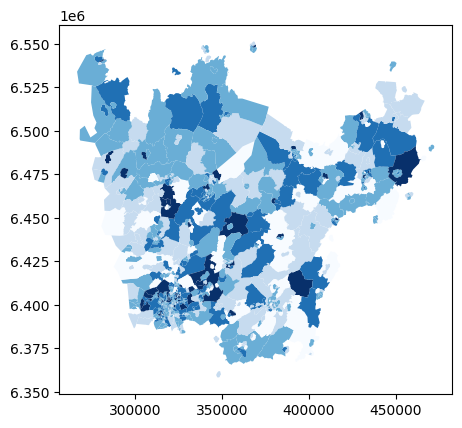

In [ ]:
vastra_areas.plot(column='Bef_201612', scheme='equal_interval', cmap='Blues')

### Задание 4.1

* Вы могли заметить, что тематическая карта не является корректной. Сначала нужно нормализовать данные, разделив численность населения и площадь территории, а только после этого построить тематическую карту.

Для вычисления площади таблицы "geometry", можно использовать такое выражение:


> table['area'] = table.geometry.area

Этот код добавляет новый столбец "area" в объект GeoDataFrame под названием "table". Новый столбец "area" содержит значения площадей геометрических объектов из столбца "geometry" в GeoDataFrame.

In [ ]:
vastra_areas['area'] = vastra_areas.geometry.area
vastra_areas

,Deso,Bef_201612,geometry,index_right,KKOD,KOMMUNKOD,KOMMUNNAMN,LANSKOD,LANSNAMN,KOM_KOD,LAN_KOD,X_poly,Y_poly,X_lan_poly,Y_lan_poly,Y_lan_po_1,area
3208,1430A0020,1397,"MULTIPOLYGON (((302807.082 6493313.675, 302244...",Kommun,414,1494,Lidk�ping,14,V�stra G�talands l�n,1494,14,385174.0,6492650.0,0.0,0,0.0,5.151756e+07
3209,1430A0030,1514,"MULTIPOLYGON (((307688.688 6500305.861, 307686...",Kommun,414,1494,Lidk�ping,14,V�stra G�talands l�n,1494,14,385174.0,6492650.0,0.0,0,0.0,1.107905e+08
3210,1430A0040,1553,"MULTIPOLYGON (((321549.193 6508056.364, 321501...",Kommun,414,1494,Lidk�ping,14,V�stra G�talands l�n,1494,14,385174.0,6492650.0,0.0,0,0.0,2.908747e+08
3212,1435A0020,1619,"MULTIPOLYGON (((298307.300 6502935.776, 298258...",Kommun,414,1494,Lidk�ping,14,V�stra G�talands l�n,1494,14,385174.0,6492650.0,0.0,0,0.0,1.331803e+08
3215,1461A0020,2118,"MULTIPOLYGON (((350873.279 6511446.384, 350839...",Kommun,414,1494,Lidk�ping,14,V�stra G�talands l�n,1494,14,385174.0,6492650.0,0.0,0,0.0,2.582946e+08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5969,1494C1120,1742,"MULTIPOLYGON (((391554.737 6486675.346, 391565...",Kommun,414,1494,Lidk�ping,14,V�stra G�talands l�n,1494,14,385174.0,6492650.0,0.0,0,0.0,2.270579e+06
5970,1494C1130,1764,"MULTIPOLYGON (((392142.188 6488430.279, 393171...",Kommun,414,1494,Lidk�ping,14,V�stra G�talands l�n,1494,14,385174.0,6492650.0,0.0,0,0.0,2.986820e+06
5971,1471A0020,1041,"MULTIPOLYGON (((398576.899 6495296.692, 402074...",Kommun,414,1494,Lidk�ping,14,V�stra G�talands l�n,1494,14,385174.0,6492650.0,0.0,0,0.0,9.442785e+07
5981,1492C1030,2483,"MULTIPOLYGON (((369392.176 6548316.729, 369309...",Kommun,414,1494,Lidk�ping,14,V�stra G�talands l�n,1494,14,385174.0,6492650.0,0.0,0,0.0,1.836107e+06


In [ ]:
vastra_areas['area'] = vastra_areas.area.values/10e6
vastra_areas

,Deso,Bef_201612,geometry,index_right,KKOD,KOMMUNKOD,KOMMUNNAMN,LANSKOD,LANSNAMN,KOM_KOD,LAN_KOD,X_poly,Y_poly,X_lan_poly,Y_lan_poly,Y_lan_po_1,area
3208,1430A0020,1397,"MULTIPOLYGON (((302807.082 6493313.675, 302244...",Kommun,414,1494,Lidk�ping,14,V�stra G�talands l�n,1494,14,385174.0,6492650.0,0.0,0,0.0,5.151756
3209,1430A0030,1514,"MULTIPOLYGON (((307688.688 6500305.861, 307686...",Kommun,414,1494,Lidk�ping,14,V�stra G�talands l�n,1494,14,385174.0,6492650.0,0.0,0,0.0,11.079046
3210,1430A0040,1553,"MULTIPOLYGON (((321549.193 6508056.364, 321501...",Kommun,414,1494,Lidk�ping,14,V�stra G�talands l�n,1494,14,385174.0,6492650.0,0.0,0,0.0,29.087474
3212,1435A0020,1619,"MULTIPOLYGON (((298307.300 6502935.776, 298258...",Kommun,414,1494,Lidk�ping,14,V�stra G�talands l�n,1494,14,385174.0,6492650.0,0.0,0,0.0,13.318032
3215,1461A0020,2118,"MULTIPOLYGON (((350873.279 6511446.384, 350839...",Kommun,414,1494,Lidk�ping,14,V�stra G�talands l�n,1494,14,385174.0,6492650.0,0.0,0,0.0,25.829463
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5969,1494C1120,1742,"MULTIPOLYGON (((391554.737 6486675.346, 391565...",Kommun,414,1494,Lidk�ping,14,V�stra G�talands l�n,1494,14,385174.0,6492650.0,0.0,0,0.0,0.227058
5970,1494C1130,1764,"MULTIPOLYGON (((392142.188 6488430.279, 393171...",Kommun,414,1494,Lidk�ping,14,V�stra G�talands l�n,1494,14,385174.0,6492650.0,0.0,0,0.0,0.298682
5971,1471A0020,1041,"MULTIPOLYGON (((398576.899 6495296.692, 402074...",Kommun,414,1494,Lidk�ping,14,V�stra G�talands l�n,1494,14,385174.0,6492650.0,0.0,0,0.0,9.442785
5981,1492C1030,2483,"MULTIPOLYGON (((369392.176 6548316.729, 369309...",Kommun,414,1494,Lidk�ping,14,V�stra G�talands l�n,1494,14,385174.0,6492650.0,0.0,0,0.0,0.183611


* Теперь необходимо создать еще один столбец. Назовем его pop_density:
pop_density = x / y, где x - численность населения y - размер территории.

> table['pop_density'] = ...

В результате в данных появится столбец плотности населения, который и следует использовать для построения тематической карты. Теперь создайте аналогичную тематическую карту с новым созданным столбцом

In [ ]:
vastra_areas['pop_density'] = vastra_areas['Bef_201612'] / vastra_areas['area']
vastra_areas

,Deso,Bef_201612,geometry,index_right,KKOD,KOMMUNKOD,KOMMUNNAMN,LANSKOD,LANSNAMN,KOM_KOD,LAN_KOD,X_poly,Y_poly,X_lan_poly,Y_lan_poly,Y_lan_po_1,area,pop_density
3208,1430A0020,1397,"MULTIPOLYGON (((302807.082 6493313.675, 302244...",Kommun,414,1494,Lidk�ping,14,V�stra G�talands l�n,1494,14,385174.0,6492650.0,0.0,0,0.0,5.151756,271.169685
3209,1430A0030,1514,"MULTIPOLYGON (((307688.688 6500305.861, 307686...",Kommun,414,1494,Lidk�ping,14,V�stra G�talands l�n,1494,14,385174.0,6492650.0,0.0,0,0.0,11.079046,136.654364
3210,1430A0040,1553,"MULTIPOLYGON (((321549.193 6508056.364, 321501...",Kommun,414,1494,Lidk�ping,14,V�stra G�talands l�n,1494,14,385174.0,6492650.0,0.0,0,0.0,29.087474,53.390679
3212,1435A0020,1619,"MULTIPOLYGON (((298307.300 6502935.776, 298258...",Kommun,414,1494,Lidk�ping,14,V�stra G�talands l�n,1494,14,385174.0,6492650.0,0.0,0,0.0,13.318032,121.564508
3215,1461A0020,2118,"MULTIPOLYGON (((350873.279 6511446.384, 350839...",Kommun,414,1494,Lidk�ping,14,V�stra G�talands l�n,1494,14,385174.0,6492650.0,0.0,0,0.0,25.829463,81.999381
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5969,1494C1120,1742,"MULTIPOLYGON (((391554.737 6486675.346, 391565...",Kommun,414,1494,Lidk�ping,14,V�stra G�talands l�n,1494,14,385174.0,6492650.0,0.0,0,0.0,0.227058,7672.052287
5970,1494C1130,1764,"MULTIPOLYGON (((392142.188 6488430.279, 393171...",Kommun,414,1494,Lidk�ping,14,V�stra G�talands l�n,1494,14,385174.0,6492650.0,0.0,0,0.0,0.298682,5905.946467
5971,1471A0020,1041,"MULTIPOLYGON (((398576.899 6495296.692, 402074...",Kommun,414,1494,Lidk�ping,14,V�stra G�talands l�n,1494,14,385174.0,6492650.0,0.0,0,0.0,9.442785,110.242900
5981,1492C1030,2483,"MULTIPOLYGON (((369392.176 6548316.729, 369309...",Kommun,414,1494,Lidk�ping,14,V�stra G�talands l�n,1494,14,385174.0,6492650.0,0.0,0,0.0,0.183611,13523.176844


In [ ]:
vastra_areas[vastra_areas['pop_density']==0.0] = np.NaN
vastra_areas[vastra_areas['pop_density']==np.inf] = np.NaN
vastra_areas = vastra_areas.dropna()


In [ ]:
vastra_areas['norm_pop_density'] = (vastra_areas['pop_density'] - vastra_areas['pop_density'].min()) / (vastra_areas['pop_density'].max() - vastra_areas['pop_density'].min())
vastra_areas

,Deso,Bef_201612,geometry,index_right,KKOD,KOMMUNKOD,KOMMUNNAMN,LANSKOD,LANSNAMN,KOM_KOD,LAN_KOD,X_poly,Y_poly,X_lan_poly,Y_lan_poly,Y_lan_po_1,area,pop_density,norm_pop_density
3208,1430A0020,1397,"MULTIPOLYGON (((302807.082 6493313.675, 302244...",Kommun,414,1494,Lidk�ping,14,V�stra G�talands l�n,1494,14,385174.0,6492650.0,0.0,0,0.0,5.151756,271.169685,0.000571
3209,1430A0030,1514,"MULTIPOLYGON (((307688.688 6500305.861, 307686...",Kommun,414,1494,Lidk�ping,14,V�stra G�talands l�n,1494,14,385174.0,6492650.0,0.0,0,0.0,11.079046,136.654364,0.000244
3210,1430A0040,1553,"MULTIPOLYGON (((321549.193 6508056.364, 321501...",Kommun,414,1494,Lidk�ping,14,V�stra G�talands l�n,1494,14,385174.0,6492650.0,0.0,0,0.0,29.087474,53.390679,0.000041
3212,1435A0020,1619,"MULTIPOLYGON (((298307.300 6502935.776, 298258...",Kommun,414,1494,Lidk�ping,14,V�stra G�talands l�n,1494,14,385174.0,6492650.0,0.0,0,0.0,13.318032,121.564508,0.000207
3215,1461A0020,2118,"MULTIPOLYGON (((350873.279 6511446.384, 350839...",Kommun,414,1494,Lidk�ping,14,V�stra G�talands l�n,1494,14,385174.0,6492650.0,0.0,0,0.0,25.829463,81.999381,0.000111
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5969,1494C1120,1742,"MULTIPOLYGON (((391554.737 6486675.346, 391565...",Kommun,414,1494,Lidk�ping,14,V�stra G�talands l�n,1494,14,385174.0,6492650.0,0.0,0,0.0,0.227058,7672.052287,0.018571
5970,1494C1130,1764,"MULTIPOLYGON (((392142.188 6488430.279, 393171...",Kommun,414,1494,Lidk�ping,14,V�stra G�talands l�n,1494,14,385174.0,6492650.0,0.0,0,0.0,0.298682,5905.946467,0.014275
5971,1471A0020,1041,"MULTIPOLYGON (((398576.899 6495296.692, 402074...",Kommun,414,1494,Lidk�ping,14,V�stra G�talands l�n,1494,14,385174.0,6492650.0,0.0,0,0.0,9.442785,110.242900,0.000180
5981,1492C1030,2483,"MULTIPOLYGON (((369392.176 6548316.729, 369309...",Kommun,414,1494,Lidk�ping,14,V�stra G�talands l�n,1494,14,385174.0,6492650.0,0.0,0,0.0,0.183611,13523.176844,0.032802


<Axes: >

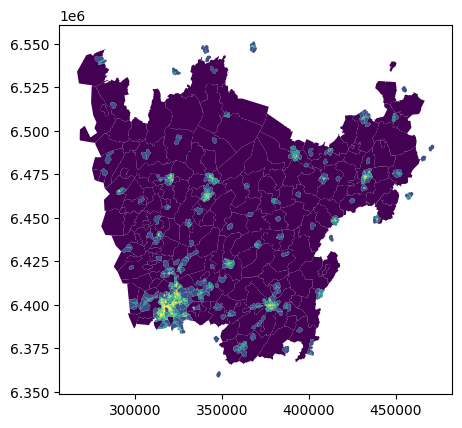

In [ ]:
vastra_areas.plot(column='norm_pop_density', scheme='quantiles', cmap='viridis')

## 4.2. Интерактивные карты в Plotly Express

Plotly Express - это новая библиотека визуализации для Python: это высокоуровневая обертка для Plotly.py, которая обеспечивает простой синтаксис для сложных диаграмм.

Вдохновленная библиотеками Seaborn и ggplot2, она специально разработана, чтобы иметь чистый, последовательный и простой в освоении API: с помощью одного импорта вы можете создавать информативные интерактивные графики, включая карты, анимацию и линии тренда за один вызов функции.

Библиотека Plotly Express полностью бесплатна: благодаря открытой лицензии MIT её можно использовать в коммерческих проектах, также Plotly Express полностью совместима с остальными компонентами экосистемы Plotly.


Ссылка на официальный сайт проекта: https://plotly.com/python/plotly-express/


### Установка plotly_express

In [ ]:
!pip install plotly_express

### Импорт данных

* Сначала мы импортируем необходимые библиотеки с помощью оператора import.

* Затем загружаем набор данных gapminder, который является встроенным набором данных в библиотеке plotly.express. Этот набор данных содержит информацию о различных странах, такую как показатели ВВП, ожидаемая продолжительность жизни и население, на протяжении нескольких лет.

* Функция gapminder.head() используется для получения первых пяти строк данных в наборе данных gapminder. Это полезно для ознакомления с набором данных и его структурой. Результат полученных данных будет показан в выводе программы.

In [ ]:
import pandas as pd
import numpy as np
import plotly.express as px

gapminder = px.data.gapminder()
gapminder.head()

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
0,Afghanistan,Asia,1952,28.801,8425333,779.445314,AFG,4
1,Afghanistan,Asia,1957,30.332,9240934,820.853030,AFG,4
2,Afghanistan,Asia,1962,31.997,10267083,853.100710,AFG,4
3,Afghanistan,Asia,1967,34.020,11537966,836.197138,AFG,4
4,Afghanistan,Asia,1972,36.088,13079460,739.981106,AFG,4


Метод `shape` возвращает размерность массива или объекта `gapminder` в виде кортежа (число строк, число столбцов).

Кортеж, который будет возвращен данным методом, содержит два элемента. Первый элемент представляет собой число строк массива `gapminder`, а второй элемент - число столбцов.

Этот код может использоваться для проверки размерности самого объекта `gapminder` и его совместимости с другими массивами или операциями. Если, например, у объекта `gapminder` 3 строки и 5 столбцов, то результат выполнения данного кода будет (3, 5).

Другими словами, данный код позволяет быстро и удобно узнать размерность объекта `gapminder`.

In [ ]:
gapminder.shape # 1704 строки и 8 столбцов

(1704, 8)

### Примеры визуализации

#### Линейный график

Для создания линейного графика используется метод px.line()

- Параметр gapminder определяет набор данных, которые будут использованы для построения графика.
- Параметр x определяет данные, которые будут использованы для горизонтальной оси.
- Параметр y определяет данные, которые будут использованы для вертикальной оси.
- Параметр color определяет данные, которые будут использованы для формирования цветовой палитры.
- Параметр line_group определяет линейную группировку, т.е. данные, которые будут использоваться для группировки данных по линиям.
- Параметр hover_name определяет данные, которые будут использоваться для подписи при наведении.
- Параметр line_shape определяет форму линии на графике.
- Параметр render_mode определяет режим рендера генерируемого изображения.

Наконец, функция fig.show() отображает график.

In [ ]:
fig = px.line(
  gapminder, # набор данных
  x="year", # данные для горизонтальной оси
  y="lifeExp", # данные для вертикальной оси
  color="continent", # данные для формирования цветой палитры
  line_group="continent", # линейная группировка
  hover_name="country", # данные для подписи при наведении
  line_shape="spline", # форма линии
  render_mode="svg", # режим рендера генерируемого изображения
)
fig.show()

#### График площадей

Для создания графика используется метод `px.area()`, которая принимает следующие параметры:

- `gapminder`: набор данных, который будет использоваться для создания графика. В данном случае, данные предполагается, что уже предварительно загружены и называются `gapminder`.
- `x="year"`: данные, которые будут использоваться для определения горизонтальной оси. В данном случае, значения будут взяты из столбца `year` набора данных `gapminder`.
- `y="pop"`: данные, которые будут использоваться для определения вертикальной оси. В данном случае, значения будут взяты из столбца `pop` набора данных `gapminder`.
- `color="continent"`: данный параметр определяет, каким образом будут раскрашены области графика. Значения для цвета будут взяты из столбца `continent` набора данных `gapminder`.
- `line_group="country"`: данный параметр определяет, каким образом будут группироваться линии на графике. Значения для группировки будут взяты из столбца `country` набора данных `gapminder`.

* После создания графика, метод `fig.show()` используется для отображения графика на экране.


Таким образом, код формирует график площади, где на горизонтальной оси отображается год, на вертикальной оси - население, области графика раскрашены в соответствии с континентами, а линии группируются по странам. Благодаря использованию библиотеки `plotly.express`, график может быть интерактивным и поддерживать взаимодействие пользователя с ним.

In [ ]:
fig = px.area(
  gapminder, # набор данных
  x="year", # данные для горизонтальной оси
  y="pop", # данные для вертикальной оси
  color="continent", # цвет
  line_group="country" # группировка линий
)
fig.show()

#### Диаграмма рассеяния

Этот код создает scatter plot (диаграмму рассеяния) с использованием библиотеки plotly.express.

* Аргумент "gapminder" представляет собой DataFrame, который будет использоваться для построения диаграммы рассеяния.

* Аргумент "x" указывает, какие данные использовать на горизонтальной оси. В данном случае, это столбец "gdpPercap" из DataFrame.

* Аргумент "y" указывает, какие данные использовать на вертикальной оси. В данном случае, это столбец "lifeExp" из DataFrame.

* Аргумент "color" указывает, как различать цвета точек на диаграмме в зависимости от категориального значения. В данном случае, это столбец "continent" из DataFrame. Каждый уникальный элемент этого столбца будет иметь свой уникальный цвет на диаграмме.

* Аргумент "size" указывает, как менять размеры окружностей точек в зависимости от значения. В данном случае, это столбец "pop" из DataFrame. Чем больше значение в этом столбце, тем больше размер окружности точки на диаграмме.

* Аргумент "size_max" определяет максимальный размер разброса окружностей на диаграмме. В данном случае, это установлено на 60.

Итак, этот код формирует диаграмму рассеяния, где на горизонтальной оси отображается ВВП на душу населения (gdpPercap), на вертикальной оси - средняя продолжительность жизни (lifeExp), цвета точек отличаются в зависимости от континента (continent), и размеры точек изменяются в зависимости от населения (pop). Диаграмма позволяет наглядно сравнить эти параметры для разных стран.

In [ ]:
px.scatter(
  gapminder # plot DataFrame dataset
  ,x="gdpPercap" # данные для горизонтальной оси
  ,y="lifeExp" # данные для вертикальной оси
  ,color="continent" # Различительные цвета
  ,size="pop" # Различать размеры окружности по критерию "pop"
  ,size_max=60 # размер разброса
)

Точки разброса также можно отображать в отдельных блоках:

- `fig = px.scatter(gapminder, x="gdpPercap", y="lifeExp")` - создает объект `fig` типа Scatter, который будет содержать наш график рассеяния. `gapminder` - это DataFrame, который содержит данные для построения графика. `x="gdpPercap"` и `y="lifeExp"` указывают, какие данные использовать для горизонтальной и вертикальной оси соответственно.

- `color="continent"` - определяет атрибут, используемый для различения цветов маркеров. В данном случае, каждый континент будет иметь свой уникальный цвет.

- `size="pop"` - определяет атрибут, используемый для различения размера маркеров. В данном случае, размер маркера будет пропорционален населению страны.

- `size_max=60` - устанавливает максимальный размер маркера до 60.

- `hover_name="country"` - указывает, что название страны будет отображаться при наведении указателя мыши на маркер.

- `animation_frame="year"` - определяет атрибут года, который будет использоваться для создания анимации. Каждый кадр анимации будет соответствовать определенному году.

- `animation_group="country"` - определяет атрибут, по которому маркеры будут группироваться при анимации. В данном случае, маркеры будут группироваться по странам.

- `facet_col="continent"` - определяет атрибут, по которому график будет разбит на несколько колонок. Каждая колонка будет соответствовать определенному континенту.

- `log_x=True` - устанавливает логарифмическое представление данных на горизонтальной оси.

- `range_x=[100,100000]` и `range_y=[25,90]` - устанавливают диапазоны значений для горизонтальной и вертикальной оси соответственно.

- `labels` - словарь, который позволяет изменить название атрибутов для большей интуитивности.

- `fig.show()` - отображает график.

Этот график позволяет наглядно представить связь между ВВП на душу населения и ожидаемой продолжительностью жизни в различных странах и континентах. Анимация и разделение на колонки по континентам позволяют сравнивать эти показатели во времени и между различными континентами. Кроме того, размер и цвет маркеров отображают информацию о населении и континентах, что облегчает визуальное восприятие данных. Общий вид графика можно настроить, изменив параметры в этом коде, чтобы лучше соответствовать целям анализа данных.

In [ ]:
fig = px.scatter(
  gapminder # данные, используемые для построения графика
  ,x="gdpPercap" # данные, используемые для горизонтальной оси
  ,y="lifeExp" # данные, используемые для вертикальной оси
  ,color="continent" # Атрибут для различения цветов.
  ,size="pop" # Атрибут для различения размера окружности
  ,size_max=60 # Максимальное значение окружности
  ,hover_name="country" # Название в верхней части визуализации графика
  ,animation_frame="year" # Атрибут года для полосы прокрутки на горизонтальной оси
  ,animation_group="country" # Группировка маркировки
  ,facet_col="continent" # Группировка по атрибутам стран
  ,log_x=True # Логарифмическое представление таблицы горизонтальных координат.
  ,range_x=[100,100000] # Диапазон значений для горизонтальной оси
  ,range_y=[25,90] # Диапазон значений по вертикальной оси
  ,labels=dict(pop="Население", # Изменение названия атрибутов для большей интуитивности
               gdpPercap="ВВП на капитал", # lifeExp="Ожидаемая продолжительность жизни", # название атрибута меняется для большей интуитивности.
               lifeExp="Ожидаемая продолжительность жизни")
)

fig.show()

#### Экспорт HTML

In [ ]:
# Сохраняем построенный график в HTML-файл, в корневую папку временного хранилища
# После сохранения скачайте его и запустите в своем браузере
fig.write_html("plotly_express_gapminder.html")

#### Тематическая карта с областями

Этот код используется для создания тематической (хороплетной) карты.

* `px.choropleth()` - это функция, которая создает хороплетную карту. В данном случае, она принимает следующие аргументы:

- `gapminder` - набор данных, который будет использоваться для построения карты.
- `locations="iso_alpha"` - указывает на столбец данных, который будет использоваться для определения местоположений на карте. В данном случае, значения из столбца `iso_alpha` будут использоваться для определения местоположений.
- `color="lifeExp"` - указывает на столбец данных, который будет определять цвета на карте. В данном случае, значения из столбца `lifeExp` будут использоваться для определения цвета.
- `hover_name="country"` - указывает на столбец данных, который будет отображаться при наведении на местоположение на карте. В данном случае, значения из столбца `country` будут отображаться при наведении.
- `animation_frame="year"` - указывает на столбец данных, который будет использоваться для создания анимации на карте. В данном случае, значения из столбца `year` будут использоваться для создания анимации, показывая изменения со временем.
- `color_continuous_scale=px.colors.sequential.Plasma` - указывает на цветовую палитру, которая будет использоваться для отображения данных на карте. В данном случае, используется палитра Plasma из библиотеки Plotly Express.
- `projection="natural earth"` - указывает на проекцию карты. В данном случае, используется глобальная проекция карты "natural earth".

В итоге, данный код создаст тематическую (хороплетную) карту, на которой каждое местоположение будет отображаться цветом, соответствующим значению из столбца `lifeExp`. При наведении на каждое местоположение будет отображаться страна из столбца `country`. Карта будет анимированной, показывая изменения со временем, используя значения из столбца `year`. Цвета на карте будут использовать цветовую палитру Plasma, а проекция карты будет глобальной "natural earth".

In [ ]:
px.choropleth(
  gapminder, # набор данных
  locations="iso_alpha", # отображение с помощью цвета color
  color="lifeExp", # выбор поля для цвета
  hover_name="country", # hover_field_name
  animation_frame="year", # аннотация
  color_continuous_scale=px.colors.sequential.Plasma, # изменение цвета
  projection="natural earth" # параметр проекции: глобальная карта
             )

#### Точечная тематическая карта

Данный код используется для создания интерактивной географической диаграммы рассеяния с использованием библиотеки Plotly Express (px).

* Переменная "fig" инициализируется с помощью функции "scatter_geo" из библиотеки Plotly Express. В качестве первого аргумента передаются данные из переменной "gapminder".

* Аргумент "locations" указывает на столбец с кодами стран (iso_alpha), по которым будут отображаться данные разными цветами на карте.

* Аргумент "color" используется для указания столбца с данными о континенте, по которому страны будут раскрашены разными цветами.

* Аргумент "hover_name" определяет столбец с данными о странах, которые будут отображаться при наведении курсора.

* Аргумент "size" указывает на столбец с данными о населении стран, которое будет отображаться размером точек на карте.

* Аргумент "animation_frame" определяет столбец с данными о годе, по которому будет происходить анимация диаграммы.

* Аргумент "projection" задает тип проекции карты, в данном случае выбрана глобальная карта с натуральным изображением Земли.

* После инициализации переменной "fig", используется метод "show()", чтобы отобразить диаграмму.

In [ ]:
fig = px.scatter_geo(
  gapminder, # данные
  locations="iso_alpha", # отображение цветом
  color="continent", # цвет
  hover_name="country", # данные при наведении
  size="pop", # размер
  animation_frame="year", # выбор фре данных
  projection="natural earth", # параметр проекции: глобальная карта
                    )

fig.show()

#### Точечная тематическая карта, сформированная с параметрами проекции по умолчанию

Данный код создает scatter plot на карте мира с использованием библиотеки plotly.

1. В параметре `gapminder` передается набор данных, который будет использоваться для создания графика.
2. Параметр `locations` определяет соответствие между данными в колонке "iso_alpha" и местоположениями на карте.
3. Параметр `color` определяет, какое поле будет определять цвет точек на графике. В данном случае, используется колонка "continent", что позволяет разделить точки по континентам.
4. Параметр `hover_name` задает данные, которые будут отображаться при наведении курсора на точку. В данном случае, используется колонка "country", что позволяет выводить название страны.
5. Параметр `size` устанавливает размер точек на графике в зависимости от значения, указанного в колонке "pop" (популяция).
6. Параметр `animation_frame` позволяет анимировать график, показывая изменение данных в соответствии с годом. Значение года берется из колонки "year".
7. Параметр `projection` был закомментирован и не будет использоваться. Он определяет проекцию карты.

In [ ]:
  px.scatter_geo(gapminder, # набор данных
  locations="iso_alpha", # соответствие и цвет для отображения цветов
  color="continent", # цвет поля для отображения
  hover_name="country", # данные для наведения курсора
  size="pop", # размер
  animation_frame="year", # выбор изменения привязки данных
  # projection="natural earth" # Удаляем параметр проекции
)

#### Создание графиков линий на географической карте

Создадим график, который показывает временные изменения для различных стран на географической карте.

* В первой строке задается имя переменной, в которую будет сохранен график. В данном случае переменная называется "fig".

* Вторая строка указывает данные, которые будут использоваться для построения графика. Они передаются в виде аргумента "gapminder". Предполагается, что "gapminder" - это набор данных, содержащий информацию о различных странах.

* Третья строка указывает, какие столбцы из набора данных будут использоваться для отображения географических местоположений стран. Здесь используется столбец "iso_alpha", который предположительно содержит коды стран в формате ISO Alpha-3.

* Четвертая строка указывает столбец, который будет использоваться для определения цвета стран на графике. В данном случае используется столбец "continent", который предположительно содержит информацию о континенте, к которому принадлежит каждая страна.

* Последняя строка указывает тип проекции для карты. В данном случае используется "orthographic", что означает, что географическая карта будет отображаться в виде сферы.

* После того, как график был создан с помощью функции px.line_geo(), отобразим его с помощью метода "show()".

In [ ]:
fig = px.line_geo(
  gapminder, # набор данных
  locations="iso_alpha", # соответствие и цвет для отображения данных
  color="continent", # цвет
  projection="orthographic") # сферическая карта
fig.show()

#### Формирование графика на географической карте:

##### Пример №1

В данном коде осуществляется формирование и вывод графика, с помощью библиотеки plotly.graph_objects.

- График представляет собой линию, соединяющую две точки на географической карте.

- Координаты этих точек задаются в списке lat (широта) и lon (долгота). В данном случае заданы координаты Нью-Йорка (40.7127 широта, -74.0059 долгота) и Лондона (51.5072 широта, 0.1275 долгота).

- Мод mode='lines' указывает, что линия будет соединять заданные точки.

* Линия имеет синий цвет и ширину 2 благодаря параметрам line = dict(width = 2, color = 'blue').

* Затем происходит настройка внешнего вида графика с помощью метода update_layout(). Здесь задается заголовок графика (title_text = 'London to NYC Great Circle'), отключается легенда (showlegend = False) и настраивается внешний вид карты с помощью параметров geo.

* Параметр resolution задает точность отображения карты (50 означает, что будет отображено 50 точек на границе страны). showland и showlakes указывают, что отображать сушу и озера. landcolor, countrycolor и lakecolor задают цвета для отображения соответствующих элементов карты.

* Параметр projection_type = "equirectangular" указывает тип проекции карты.

* Параметры lataxis и lonaxis позволяют настроить интервалы и шаги для отображения широты и долготы на оси координат.

* Наконец, карта отображается с помощью метода show().

In [ ]:
import plotly.graph_objects as go

fig = go.Figure(data=go.Scattergeo(
    lat = [40.7127, 51.5072],
    lon = [-74.0059, 0.1275],
    mode = 'lines',
    line = dict(width = 2, color = 'blue'),
))

fig.update_layout(
    title_text = 'London to NYC Great Circle',
    showlegend = False,
    geo = dict(
        resolution = 50,
        showland = True,
        showlakes = True,
        landcolor = 'rgb(204, 204, 204)',
        countrycolor = 'rgb(204, 204, 204)',
        lakecolor = 'rgb(255, 255, 255)',
        projection_type = "equirectangular",
        coastlinewidth = 2,
        lataxis = dict(
            range = [20, 60],
            showgrid = True,
            dtick = 10
        ),
        lonaxis = dict(
            range = [-100, 20],
            showgrid = True,
            dtick = 20
        ),
    )
)

fig.show()

##### Пример №2

Используя библиотеки pandas и plotly, создадим интерактивный график с полетными маршрутами американской авиакомпании American Airlines в феврале 2011 года.

* В начале кода импортируются необходимые библиотеки: pandas и plotly. Библиотека pandas используется для работы с данными, а plotly для создания интерактивных графиков.

* Затем загружаем два набора данных из Интернета:

      df_airports: данные о аэропортах США, включая их координаты
      df_flight_paths: данные о полетных маршрутах American Airlines, включая координаты начала и конца маршрута

* Далее создается график типа Scattergeo с помощью функции go.Figure(). Scattergeo используется для отображения точек на географической карте.

* Первая точка графика представляет собой маркеры аэропортов. Географические координаты аэропортов берутся из столбцов 'long' и 'lat' DataFrame df_airports. Каждая точка имеет текстовую информацию, отображаемую при наведении курсора (в данном случае названия аэропортов). Маркеры имеют размер 2 и красный цвет, с прозрачными линиями.

* После добавления аэропортов на карту, добавляются линии полетных маршрутов с помощью цикла for. Координаты начальной и конечной точек каждого маршрута берутся из столбцов 'start_lon', 'start_lat', 'end_lon' и 'end_lat' DataFrame df_flight_paths. Линии имеют красный цвет и разную прозрачность в зависимости от значения столбца 'cnt' (количество полетов).

* После этого производится настройка макета графика. Заголовок графика задается с помощью свойства title_text.

* Настройки географической карты указываются в свойстве geo. В данном случае используется проекция 'azimuthal equal area' для Северной Америки.

* Наконец, код выводит график на экран с помощью функции show().

* В результате выполнения этого кода будет получен интерактивный график с полетными маршрутами American Airlines в Северной Америке, с аэропортами, текстовой информацией и цветовыми линиями, отображающими интенсивность полетов по маршрутам.

In [ ]:
import pandas as pd
import plotly
from plotly.graph_objs import *


df_airports = pd.read_csv('https://raw.githubusercontent.com/plotly/datasets/master/2011_february_us_airport_traffic.csv')
df_airports.head()

df_flight_paths = pd.read_csv('https://raw.githubusercontent.com/plotly/datasets/master/2011_february_aa_flight_paths.csv')
df_flight_paths.head()



fig = go.Figure()

fig.add_trace(go.Scattergeo(
    locationmode = 'USA-states',
    lon = df_airports['long'],
    lat = df_airports['lat'],
    hoverinfo = 'text',
    text = df_airports['airport'],
    mode = 'markers',
    marker = dict(
        size = 2,
        color = 'rgb(255, 0, 0)',
        line = dict(
            width = 3,
            color = 'rgba(68, 68, 68, 0)'
        )
    )))

for i in range(len(df_flight_paths)):
    fig.add_trace(
        go.Scattergeo(
            locationmode = 'USA-states',
            lon = [df_flight_paths['start_lon'][i], df_flight_paths['end_lon'][i]],
            lat = [df_flight_paths['start_lat'][i], df_flight_paths['end_lat'][i]],
            mode = 'lines',
            line = dict(width = 1,color = 'red'),
            opacity = float(df_flight_paths['cnt'][i]) / float(df_flight_paths['cnt'].max()),
        )
    )

fig.update_layout(
    title_text = 'Feb. 2011 American Airline flight paths<br>(Hover for airport names)',
    showlegend = False,
    geo = dict(
        scope = 'north america',
        projection_type = 'azimuthal equal area',
        showland = True,
        landcolor = 'rgb(243, 243, 243)',
        countrycolor = 'rgb(204, 204, 204)',
    ),
)

fig.show()

#### Задание 4.2

**Постройте интерактивную карту мира, где каждая страна будет окрашена в цвет в зависимости от ее численности её населения.**

Используйте датасет "gapminder" с информацией о населении разных стран на разные годы.

In [ ]:
gapminder = px.data.gapminder()
gapminder.head(10)

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
0,Afghanistan,Asia,1952,28.801,8425333,779.445314,AFG,4
1,Afghanistan,Asia,1957,30.332,9240934,820.853030,AFG,4
2,Afghanistan,Asia,1962,31.997,10267083,853.100710,AFG,4
3,Afghanistan,Asia,1967,34.020,11537966,836.197138,AFG,4
4,Afghanistan,Asia,1972,36.088,13079460,739.981106,AFG,4
5,Afghanistan,Asia,1977,38.438,14880372,786.113360,AFG,4
6,Afghanistan,Asia,1982,39.854,12881816,978.011439,AFG,4
7,Afghanistan,Asia,1987,40.822,13867957,852.395945,AFG,4
8,Afghanistan,Asia,1992,41.674,16317921,649.341395,AFG,4
9,Afghanistan,Asia,1997,41.763,22227415,635.341351,AFG,4


In [ ]:
px.choropleth(
  gapminder, # набор данных
  locations="iso_alpha", # отображение с помощью цвета color
  color="pop", # выбор поля для цвета
  hover_name="country", # hover_field_name
  animation_frame="year", # аннотация
  color_continuous_scale=px.colors.sequential.Plasma, # изменение цвета
  projection="natural earth" # параметр проекции: глобальная карта
             )

**Постройте интерактивную диаграмму рассеяния (точечная) с распределением ВВП на душу населения (Используйте датасет "gapminder"):**

In [ ]:
fig = px.scatter_geo(
  gapminder, # данные
  locations="iso_alpha", # отображение цветом
  color="continent", # цвет
  hover_name="country", # данные при наведении
  size="gdpPercap", # размер
  animation_frame="year", # выбор фре данных
  projection="natural earth", # параметр проекции: глобальная карта
                    )

fig.show()

**Создайте интерактивную карту, отображающую данные о трафике в аэропортах США в феврале 2011 года.**

Цель: Создать интерактивную карту, отображающую данные о трафике в аэропортах США в феврале 2011 года.

Шаги:

1. Загрузите даннные из датасета по ссылке: https://raw.githubusercontent.com/plotly/datasets/master/2011_february_us_airport_traffic.csv

2. Используя библиотеку plotly, создайте интерактивную карту США.

3. Добавьте на карту маркеры для каждого аэропорта, используя географические координаты из датасета. Размер и цвет маркеров можно выбрать по желанию.

4. Добавьте всплывающее окно для каждого маркера, отображающее информацию о конкретном аэропорте, такую как название, город и количество пассажиров.

5. Добавьте легенду, объясняющую значения цветов маркеров.

6. Добавьте масштабируемость и возможность перетаскивания карты.

7. Добавьте заголовок для карты, указывающий на то, что она отображает данные о трафике в аэропортах США в феврале 2011 года.

(Ниже приведен пример)

In [ ]:
# Ваш код

In [ ]:
df_airport_traffic = pd.read_csv('https://raw.githubusercontent.com/plotly/datasets/master/2011_february_us_airport_traffic.csv')
df_airport_traffic

,iata,airport,city,state,country,lat,long,cnt
0,ORD,Chicago O'Hare International,Chicago,IL,USA,41.979595,-87.904464,25129
1,ATL,William B Hartsfield-Atlanta Intl,Atlanta,GA,USA,33.640444,-84.426944,21925
2,DFW,Dallas-Fort Worth International,Dallas-Fort Worth,TX,USA,32.895951,-97.037200,20662
3,PHX,Phoenix Sky Harbor International,Phoenix,AZ,USA,33.434167,-112.008056,17290
4,DEN,Denver Intl,Denver,CO,USA,39.858408,-104.667002,13781
...,...,...,...,...,...,...,...,...
216,EAU,Chippewa Valley Regional,Eau Claire,WI,USA,44.865257,-91.485072,48
217,DBQ,Dubuque Municipal,Dubuque,IA,USA,42.402959,-90.709167,48
218,RST,Rochester International,Rochester,MN,USA,43.908826,-92.497987,37
219,UTM,Tunica Municipal Airport,Tunica,MS,USA,34.681499,-90.348816,32


In [ ]:
fig_traffic = px.scatter_geo(df_airport_traffic,
  lat='lat',
  lon='long',
  color='cnt',
  hover_name='airport',
  title='Данные о трафике в аэропортах США в феврале 2011 года',
  projection="natural earth"
    )

fig_traffic.show()

## 4.3. Интерактивные карты в Folium

[Folium](https://python-visualization.github.io/folium/) - это библиотека Python, позволяющая создавать интерактивные карты на основе популярной javascript-библиотеки [Leaflet](https://leafletjs.com/).

In [ ]:
import os
import folium

Этот код создает две папки - "data" и "output".
Сначала происходит проверка существования папки "data" с помощью функции `os.path.exists()`. Если папка не существует, тогда с помощью `os.mkdir()` она создается.
Затем происходит аналогичная проверка и создание папки "output".
Цель данного кода - создать папки для хранения данных и результатов работы скрипта. Если папки уже существуют, дополнительно создавать их не нужно.

In [ ]:
data_folder = 'data'
output_folder = 'output'

if not os.path.exists(data_folder):
    os.mkdir(data_folder)
if not os.path.exists(output_folder):
    os.mkdir(output_folder)

Для расчета маршрутов мы будем использовать [OpenRouteService API](https://openrouteservice.org/). Для использования нужно зарегистрировать бесплатный аккаунт и создать API-ключ. Если у вас уже есть учетная запись, ключ API можно получить на панели [OpenRouteService Dashboard](https://openrouteservice.org/dev/#/home). Введите свой API-ключ ниже:

In [ ]:
ORS_API_KEY = '5b3ce3597851110001cf6248494798a6d74641a385d3eb07b029a92b' # Уже введен

### 4.3.1. Основы Folium

Мы познакомимся с основами фолиума, создав интерактивную карту, показывающую направления движения между двумя выбранными населенными пунктами. Для начала определим координаты двух городов.

In [ ]:
san_francisco = (37.7749, -122.4194)
new_york = (40.661, -73.944)

Для создания карты мы инициализируем класс `folium.Map()`, который создает объект карты с базовой картой по умолчанию. Для отображения карты в блокноте Jupyter достаточно ввести имя объекта карты.

In [ ]:
m = folium.Map()
m

Карта по умолчанию занимает всю ширину блокнота Jupyter, что затрудняет навигацию по ней. Конструктор `Map()` поддерживает параметры `width` и `height`, которые управляют размером карты, но в итоге под картой остается много лишнего пустого пространства. Более предпочтительным способом получения карты точного размера является создание сначала объекта *Figure*, а затем добавление к нему объекта map.

In [ ]:
from folium import Figure
fig = Figure(width=800, height=400)
m = folium.Map(location=[39.83, -98.58], zoom_start=4)
fig.add_child(m)

Объектом карты `m` можно манипулировать, добавляя в него различные элементы. В отличие от того, как работают объекты Matplotlib, объект карты не опустошается при отображении. Поэтому вы можете визуализировать и постепенно добавлять в него элементы. Давайте добавим на карту несколько маркеров, координаты которых мы проинициализировали ранее, используя класс [`folium.map.Marker`](https://python-visualization.github.io/folium/modules.html#folium.map.Marker).

In [ ]:
folium.Marker(san_francisco, popup='San Francisco').add_to(m)
folium.Marker(new_york, popup='New York').add_to(m)
m

Цвет и иконку маркеров можно поменять. Варианты создания иконок можно найти в классе [`folium.map.Icon`](https://python-visualization.github.io/folium/modules.html#folium.map.Icon). Этот класс поддерживает огромное количество иконок из библиотек [fontawesome icons](https://fontawesome.com/search?m=free&c=maps) и [bootstrap icons](https://getbootstrap.com/docs/3.3/components/). Отсюда можно выбрать имя иконки, чтобы использовать ее в своей карте Folium. Параметр `prefix` может быть *fa* для иконок FontAwesome или *glyphicon* для Bootstrap3.

In [ ]:
from folium import Figure
fig = Figure(width=800, height=400)
m = folium.Map(location=[39.83, -98.58], zoom_start=4)
folium.Marker(san_francisco, popup='San Francisco',
              icon=folium.Icon(
                  color='green', icon='crosshairs', prefix='fa')
             ).add_to(m)
folium.Marker(new_york, popup='New York',
              icon=folium.Icon(color='red', icon='crosshairs', prefix='fa')
             ).add_to(m)
fig.add_child(m)


Для отображения маршрута на карте, будем использовать данные от сервиса OpenRouteService API.

1. Импортируем модуль requests.
2. Задаём координаты для городов Сан-Франциско и Нью-Йорка.
3. Создаём словарь parameters, содержащий параметры для запроса к API. В параметрах указывается ключ API (переменная ORS_API_KEY), начальные и конечные координаты для маршрута.
4. Выполняем GET-запрос к API, используя библиотеку requests и передавая параметры запроса.
5. Проверяем статус ответа: если код статуса равен 200, то запрос выполнен успешно.
Если запрос выполнен успешно, выводится сообщение 'Request successful.', и данные из ответа (в формате JSON) сохраняются в переменную data.
6. Если запрос не выполнен успешно, выводится сообщение 'Request failed.'.

Код может быть использован для получения маршрута от Сан-Франциско до Нью-Йорка с использованием API OpenRouteService.

In [ ]:
import requests

san_francisco = (37.7749, -122.4194)
new_york = (40.661, -73.944)

parameters = {
    'api_key': ORS_API_KEY,
    'start' : '{},{}'.format(san_francisco[1], san_francisco[0]),
    'end' : '{},{}'.format(new_york[1], new_york[0])
}

response = requests.get(
    'https://api.openrouteservice.org/v2/directions/driving-car', params=parameters)

if response.status_code == 200:
    print('Request successful.')
    data = response.json()
else:
    print('Request failed.')


Request successful.


**Извлекаем координаты для направления движения:**

- `data` - это переменная, содержащая ответ от API OpenRouteService
- `data['features']` - это список объектов "features" в ответе API, которые представляют маршруты
- `data['features'][0]` - это первый (в данном случае, единственный) объект "features" в списке, который содержит информацию о маршруте
- `data['features'][0]['geometry']` - это объект "geometry" внутри выбранного объекта "features", который содержит геометрическую информацию о маршруте
- `data['features'][0]['geometry']['coordinates']` - это список координат, определяющих маршрут. Каждая координата представлена в виде пары чисел (долгота, широта). Этот список координат является результатом выполнения запроса к API OpenRouteService и может быть использован для отображения маршрута на карте при помощи библиотеки folium.

In [ ]:
route= data['features'][0]['geometry']['coordinates']

In [ ]:
route[:5]

[[-122.419446, 37.774936],
 [-122.41934, 37.77502],
 [-122.419176, 37.775164],
 [-122.418776, 37.775474],
 [-122.418675, 37.77555]]

Координаты, возвращаемые API OpenRouteService, имеют порядок [X,Y] (т.е. [долгота, широта]), в то время как Folium требует координаты в порядке [Y,X] (т.е. [широта, долгота]). Мы можем поменять их местами перед построением графика.

In [ ]:
route_xy = []
for x, y in route:
    route_xy.append((y,x))
route_xy[:5]

[(37.774936, -122.419446),
 (37.77502, -122.41934),
 (37.775164, -122.419176),
 (37.775474, -122.418776),
 (37.77555, -122.418675)]

Более простым способом решения этой задачи является использование List Comprehension

In [ ]:
route_xy = [(y, x) for x, y in route]
route_xy[:5]

[(37.774936, -122.419446),
 (37.77502, -122.41934),
 (37.775164, -122.419176),
 (37.775474, -122.418776),
 (37.77555, -122.418675)]

Извлекаем данные о маршруте, возвращаемые API, которые содержат общее расстояние в метрах, а также сводную информации:

1. `summary = data['features'][0]['properties']['summary']` - получает сводную информацию о маршруте из словаря `data`. Эта информация находится внутри структуры JSON и содержит ключ 'summary'. Если вам нужна более подробная информация, вы также можете получить доступ к дополнительным данным, таким как время в пути или расход топлива, используя другие ключи внутри `['properties']`.

2. `distance = round(summary['distance']/1000)` - извлекает расстояние из сводной информации и делит его на 1000, чтобы получить значение в километрах. Результат округляется до ближайшего целого числа. `distance` содержит округленное значение расстояния в километрах.

3. `tooltip = 'Driving Distance: {}km'.format(distance)` - форматирует строку, чтобы включить значение `distance` и создает подсказку для отображения на карте. Например, если `distance` равно 10, строка будет "Driving Distance: 10km". `tooltip` содержит сформированную подсказку.

In [ ]:
summary = data['features'][0]['properties']['summary']
distance = round(summary['distance']/1000)
tooltip = 'Driving Distance: {}km'.format(distance)
tooltip

'Driving Distance: 4693km'

Для добавления линии на карту мы можем использовать класс [`folium.vector_layers.Polyline`](https://python-visualization.github.io/folium/modules.html#folium.vector_layers.PolyLine). Класс имеет параметр `smooth_factor`, который может быть использован для упрощения отображения линии при уменьшении масштаба. Установка большего значения этого параметра приводит к улучшению производительности.

In [ ]:
folium.PolyLine(route_xy, tooltip=tooltip, smooth_factor=1).add_to(m)
m

Карты Folium могут быть сохранены в HTML-файл путем вызова функции `save()` на объекте карты:

1. Программа создает переменную `output_folder`, в которой хранится имя папки, в которую будет сохранен файл. В данном примере имя папки установлено как "output".

2. Затем проверяется, существует ли уже папка с указанным именем (output). Если папка не существует, то создается новая папка с помощью функции `os.mkdir(output_folder)`. Это делается, чтобы убедиться, что папка существует перед сохранением файла.

3. Далее создается переменная `output_path` с помощью функции `os.path.join()`. Она объединяет имя папки и имя файла ("directions.html") в один путь к файлу.

4. Наконец, вызывается метод `save()` объекта `m` (предполагается, что `m` - объект карты), чтобы сохранить карту в указанный путь `output_path`. То есть, HTML файл карты будет сохранен в папке "output" под именем "directions.html".

In [ ]:
output_folder = 'output'
if not os.path.exists(output_folder):
    os.mkdir(output_folder)
output_path = os.path.join(output_folder, 'directions.html')
m.save(output_path)

----

### 4.3.2 Визуализация набора точек на карте:

В последнем подразделе рассмотрим, как добавлять массив точек на карту с помощью Folium. Составим карту всех городов региона Вастра.

* На первой строке создается объект m класса folium.Map. Он представляет собой пустую карту, которую мы будем заполнять данными. В качестве аргументов конструктору передается location - координаты центра карты, tiles - тип базовой карты (пустая строка означает использование стандартной базовой карты), и zoom_start - начальный уровень масштабирования карты.

* На второй строке используется метод add_to, чтобы добавить геоданные vastra_cities в виде объекта folium.GeoJson на карту m. Это может быть полигон, линия или точка на карте.

* На третьей строке используется метод add_to, чтобы добавить элемент управления слоями (LayerControl) на карту m. Этот элемент позволяет пользователю выбирать, какие слои отображать и скрывать на карте.

> Наконец, в последней строке переменная m возвращается, чтобы показать созданную карту.

In [ ]:
m = folium.Map(
    location=[57.69882, 11.973229],
    tiles='CartoDB dark_matter',
    zoom_start=8,
)

folium.GeoJson(vastra_cities).add_to(m)
folium.LayerControl().add_to(m)
m

In [ ]:
vastra_areas.head()

,Deso,Bef_201612,geometry,index_right,KKOD,KOMMUNKOD,KOMMUNNAMN,LANSKOD,LANSNAMN,KOM_KOD,LAN_KOD,X_poly,Y_poly,X_lan_poly,Y_lan_poly,Y_lan_po_1,area,pop_density,norm_pop_density
3208,1430A0020,1397,"MULTIPOLYGON (((302807.082 6493313.675, 302244...",Kommun,414,1494,Lidk�ping,14,V�stra G�talands l�n,1494,14,385174.0,6492650.0,0.0,0,0.0,5.151756,271.169685,0.000571
3209,1430A0030,1514,"MULTIPOLYGON (((307688.688 6500305.861, 307686...",Kommun,414,1494,Lidk�ping,14,V�stra G�talands l�n,1494,14,385174.0,6492650.0,0.0,0,0.0,11.079046,136.654364,0.000244
3210,1430A0040,1553,"MULTIPOLYGON (((321549.193 6508056.364, 321501...",Kommun,414,1494,Lidk�ping,14,V�stra G�talands l�n,1494,14,385174.0,6492650.0,0.0,0,0.0,29.087474,53.390679,0.000041
3212,1435A0020,1619,"MULTIPOLYGON (((298307.300 6502935.776, 298258...",Kommun,414,1494,Lidk�ping,14,V�stra G�talands l�n,1494,14,385174.0,6492650.0,0.0,0,0.0,13.318032,121.564508,0.000207
3215,1461A0020,2118,"MULTIPOLYGON (((350873.279 6511446.384, 350839...",Kommun,414,1494,Lidk�ping,14,V�stra G�talands l�n,1494,14,385174.0,6492650.0,0.0,0,0.0,25.829463,81.999381,0.000111


### Задание 4.3. Построение интерактивных карт в Folium

**Ниже приведен полный код для создания интерактивной карты с указанием направления движения между двумя городами. Замените пункты отправления и назначения выбранными вами городами и создайте интерактивную карту.**

In [ ]:
import folium
import requests


origin = (41.85003, -87.65005)
origin_name = 'Chicago'
destination = (36.188110, -115.176468)
destination_name = 'Las Vegas'
map_center = (39.83, -98.58)
ORS_API_KEY = '5b3ce3597851110001cf6248494798a6d74641a385d3eb07b029a92b'

parameters = {
    'api_key': ORS_API_KEY,
    'start' : '{},{}'.format(origin[1], origin[0]),
    'end' : '{},{}'.format(destination[1], destination[0])
}

response = requests.get(
    'https://api.openrouteservice.org/v2/directions/driving-car', params=parameters)

if response.status_code == 200:
    print('Request successful.')
    data = response.json()
else:
    print('Request failed.')

route= data['features'][0]['geometry']['coordinates']
summary = data['features'][0]['properties']['summary']

route_xy = [(y, x) for x, y in route]
distance = round(summary['distance']/1000)
tooltip = 'Driving Distance: {}km'.format(distance)

from folium import Figure
fig = Figure(width=800, height=400)

m = folium.Map(location=map_center, zoom_start=4)
folium.Marker(origin, popup=origin_name,
              icon=folium.Icon(
                  color='green', icon='crosshairs', prefix='fa')
             ).add_to(m)
folium.Marker(destination, popup=destination_name,
              icon=folium.Icon(color='red', icon='crosshairs', prefix='fa')
             ).add_to(m)
folium.PolyLine(route_xy, tooltip=tooltip).add_to(m)
fig.add_child(m)

Request successful.


**Базовые карты, доступные в в Folium: попробуйте визуализировать некоторые из них (минимум 3).**

Значения параметра tiles:

1. "OpenStreetMap"
2. "Mapbox Bright" (ограниченное количество уровней масштабирования для бесплатной версии)
3. "Mapbox Control Room" (ограниченные уровни масштабирования для бесплатной версии)
4. "Stamen"
5. "Cloudmade" (необходимо получить API-ключ).
6. "Mapbox" (необходимо получить API-ключ)
7. "CartoDB" (tiles="cartodb positron")

In [ ]:
m = folium.Map(
    location=[55.7, 37.6],
    tiles='OpenStreetMap',
    zoom_start=10,
)

folium.GeoJson(vastra_cities).add_to(m)
folium.LayerControl().add_to(m)
m

In [ ]:
m = folium.Map(
    location=[55.7, 37.6],
    tiles='cartodb positron',
    zoom_start=10,
)

folium.GeoJson(vastra_cities).add_to(m)
folium.LayerControl().add_to(m)
m

In [ ]:
m = folium.Map(
    location=[55.7, 37.6],
    tiles='cartodbdark_matter',
    zoom_start=10,
)

folium.GeoJson(vastra_cities).add_to(m)
folium.LayerControl().add_to(m)
m